# Bayesian Framework: Numerical Verification Benchmarks
---
**Manuscript Reference:** Section 4 (Subsections 4.1, 4.2, and 4.3)

**Objective:** 
This notebook executes the numerical verification phase of the proposed framework. It evaluates parameter estimation consistency in low-dimensional mathematical formulations and verifies the direct integration of the OpenSeesPy finite element solver via custom PyTensor operators under controlled noise baselines.

All computations are entirely self-contained, and synthetic datasets are generated programmatically within the cells below.

---
## 1. Benchmark 1: Quadratic Regression (Section 4.1)
Verification of Bayesian parameter estimation using synthetic linear-in-the-parameters data.

## 2. Benchmark 2: Sinusoidal Model (Section 4.2)
Evaluation of non-linear parameter identification and scale parameter ($\sigma$) convergence.

## 3. Benchmark 3: Beam Deflection Model (Section 4.3)
Verification of the custom PyTensor operator bridging the numerical finite element solver with the PyMC inference engine.

## Libraries

Installing Libraries

In [ ]:
!pip install numpy matplotlib pymc arviz pandas xarray openseespy

Importing Libraries

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from matplotlib.ticker import MultipleLocator
import subprocess
from openseespy.opensees import *
import math

from pymc import HalfCauchy, Model, Normal, sample

print(f"Running on PyMC v{pm.__version__}")

Plotting Configuration

In [ ]:
plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({"axes.grid" : True, "grid.color": "0.8","lines.color": "k", "grid.linewidth": 0.5, "axes.edgecolor": "0.8", 'font.size': 20,
                    'xtick.minor.bottom': True, 'ytick.minor.left': True, 'xtick.bottom': True, 'ytick.left': True,
                     "font.family": "STIXGeneral", "mathtext.fontset": "stix"})

# Configurar rcParams para tick marks
# plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'out'
# plt.rcParams['xtick.major.size'] = 4
# plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['ytick.major.width'] = 1
# plt.rcParams['xtick.minor.size'] = 2
# plt.rcParams['xtick.minor.width'] = 0.5
# plt.rcParams['ytick.minor.size'] = 4
# plt.rcParams['ytick.minor.width'] = 1

## Log-like OP

In [ ]:
# define a pytensor Op for our likelihood function
class LogLike(pt.Op):

    itypes = [pt.dvector,pt.dscalar]   # expects a vector of parameter values when called
    otypes = [pt.dscalar]  # outputs a single scalar value (the log likelihood)

    def __init__(self, loglike, data, x):
      #, sigma):
        """
        Initialise the Op with various things that our log-likelihood function
        requires. Below are the things that are needed in this particular
        example.

        Parameters
        ----------
        loglike:
            The log-likelihood (or whatever) function we've defined
        data:
            The "observed" data that our log-likelihood function takes in
        x:
            The dependent variable (aka 'x') that our model requires
        sigma:
            The noise standard deviation that our function requires.
        """
        # add inputs as class attributes
        self.likelihood = loglike
        self.data = data
        self.x = x
        self.sigma = 1#sigma

    def perform(self, node, inputs, outputs):
        # the method that is used when calling the Op
        theta,sigma = inputs  # this will contain my variables

        # call the log-likelihood function
        logl = self.likelihood(theta, sigma, self.x, self.data)#, sigma)

        outputs[0][0] = np.array(logl)  # output the log-likelihood

# Benchmark 1: Quadratic Regression (Section 4.1)

In [ ]:
size = 2000
true_quad_coeff = 5
true_slope = 3
true_intercept = 2

x = np.linspace(0, 10, size)

# y = a + b*x
true_regression_line = true_intercept + true_slope * x + true_quad_coeff * x**2

sigma = 20
noise = np.random.randn(size)*sigma

# add noise
y = true_regression_line + noise

data = pd.DataFrame(dict(x=x, y=y))

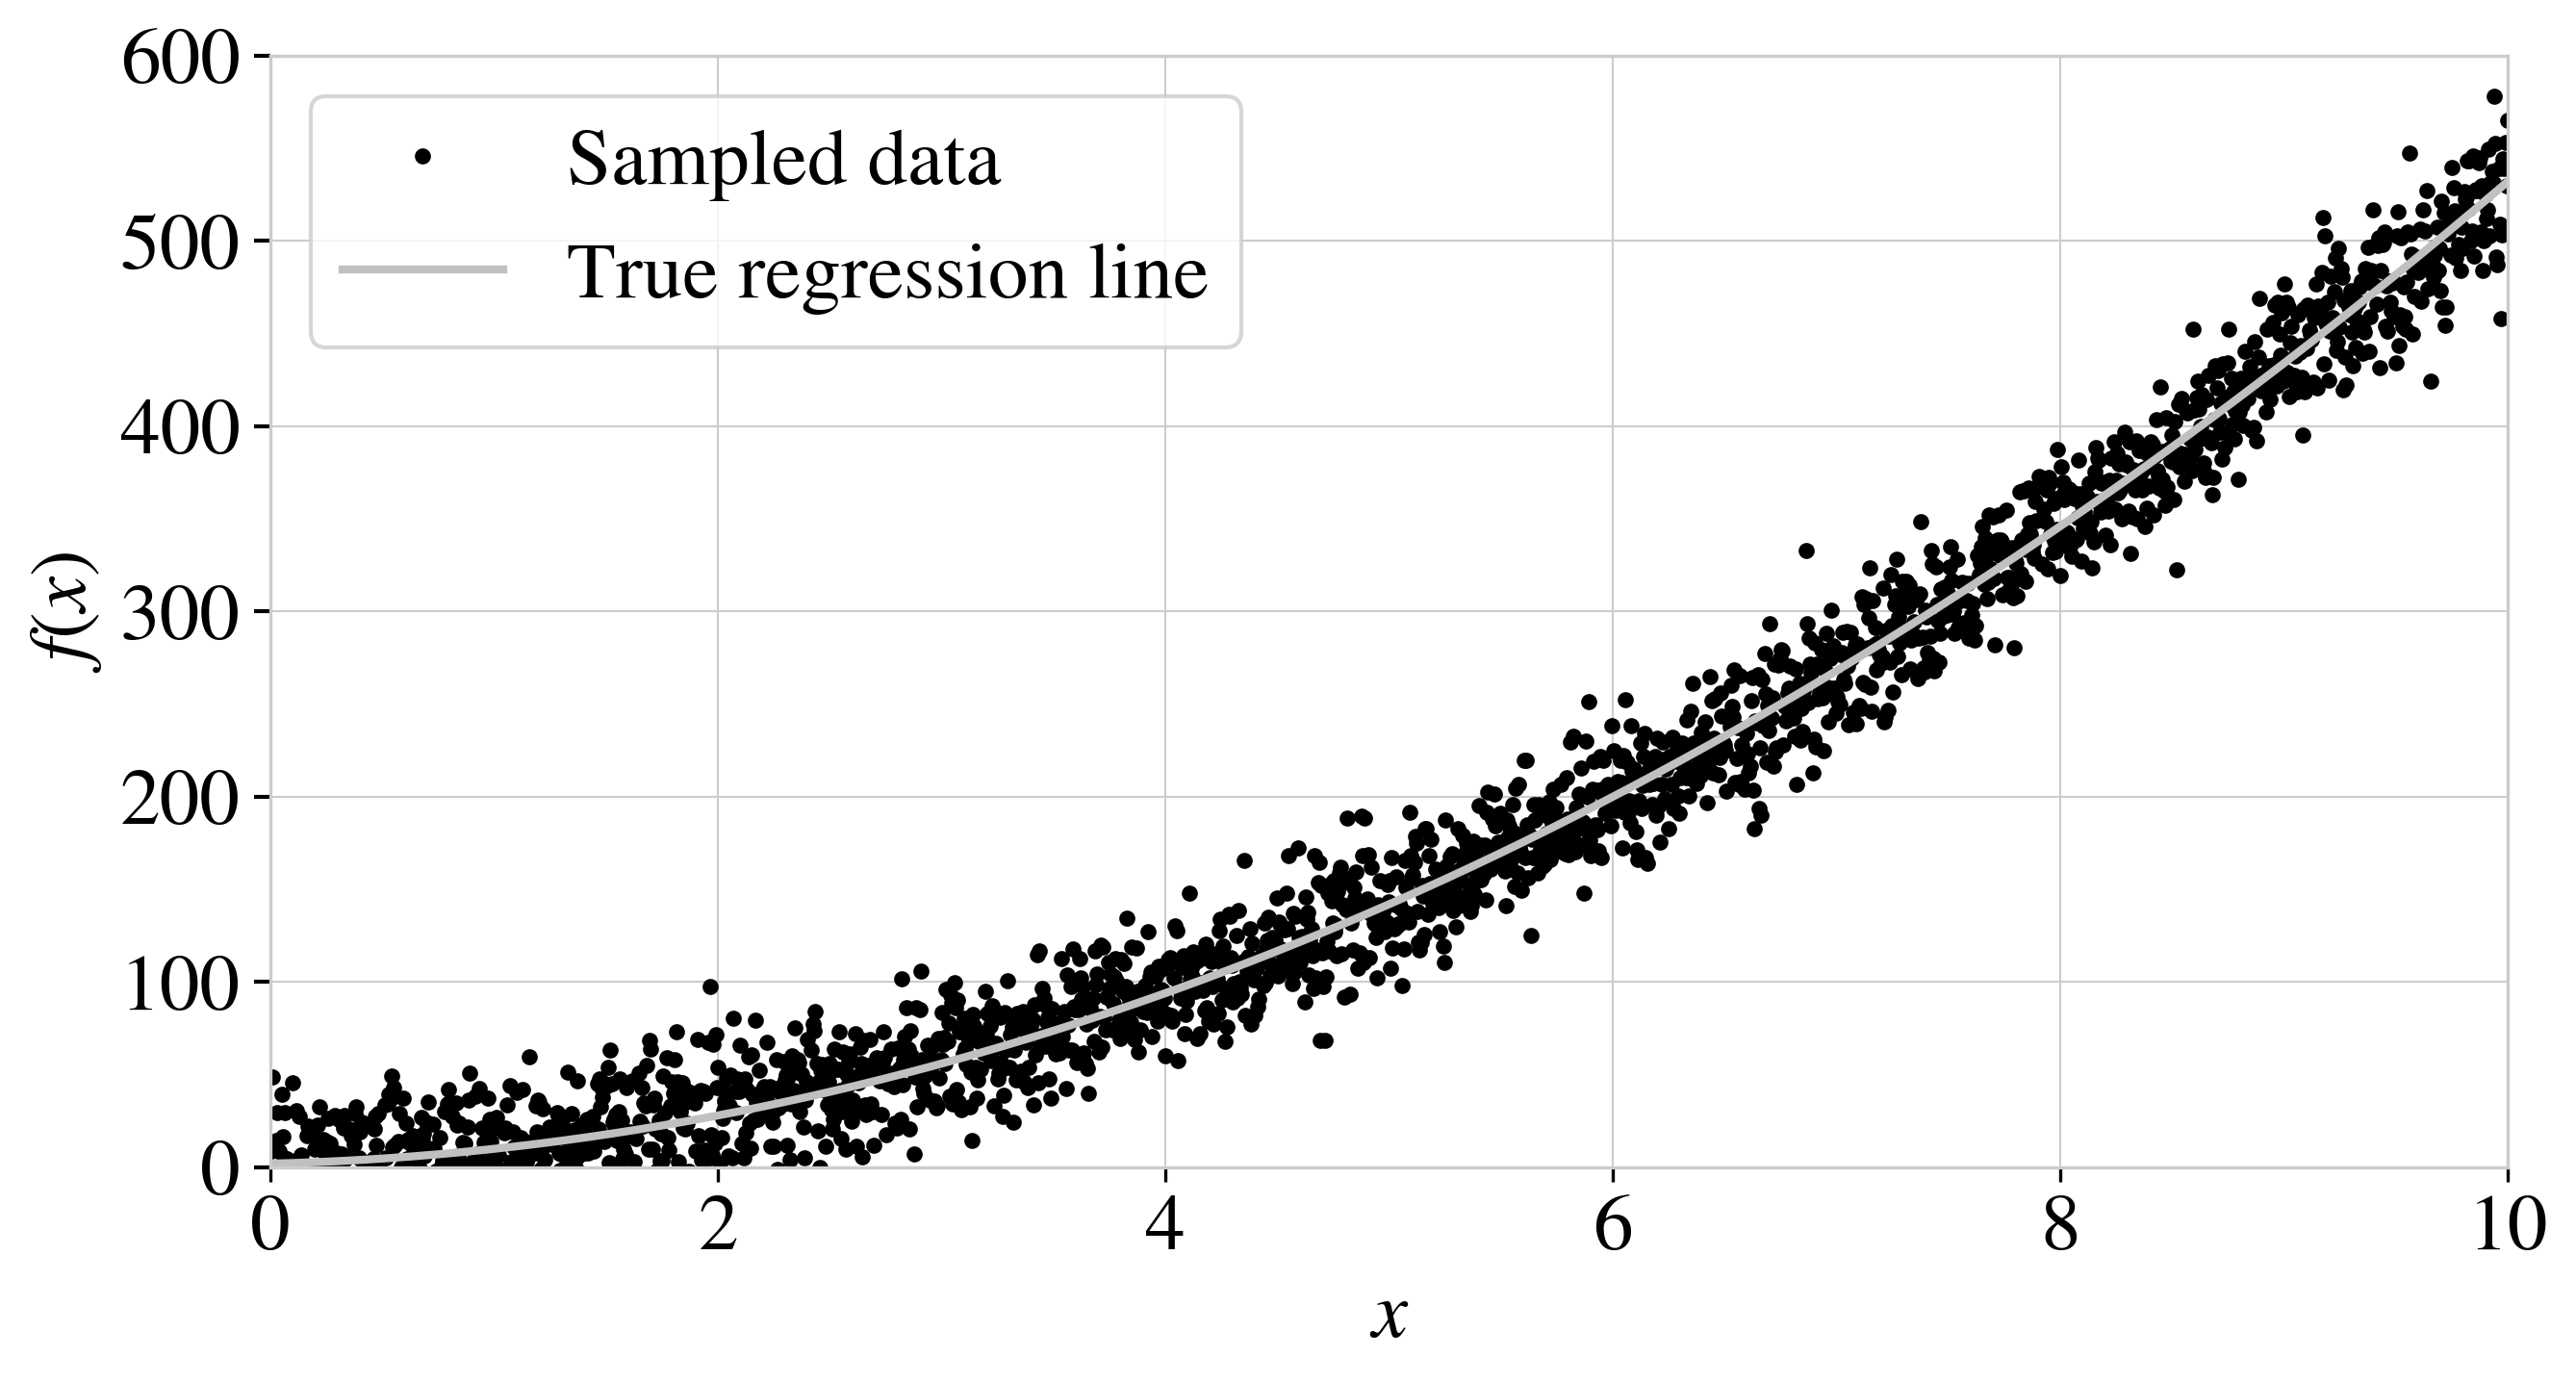

In [ ]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, xlabel="$x$", ylabel="$f(x)$")
ax.plot(x, y, ".", label="Sampled data", color='k')
ax.plot(x, true_regression_line, color='silver', label="True regression line", lw=2.0)
plt.xlim([0, 10])
plt.ylim([0, 600])
plt.legend(loc=0);
plt.show()

In [ ]:
# Analyzing the model

# Define linear model
with pm.Model() as linear_model:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    slope = pm.Normal('slope', mu=0, sigma=10)
    noise = pm.HalfNormal('noise', sigma=1)

    # Model
    y_estimated_linear = intercept + slope * x

    # Likelihood
    likelihood_linear = pm.Normal('y_linear', mu=y_estimated_linear, sigma=noise, observed=y)

    # obtain starting values via MAP
    start = pm.find_MAP()

    # Sample
    linear_trace = pm.sample(2000, start=start)

# Define quadratic model
with pm.Model() as quad_model:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    slope = pm.Normal('slope', mu=0, sigma=10)
    quad_coeff = pm.Normal('quad_coeff', mu=0, sigma=10)
    noise = pm.HalfNormal('noise', sigma=1)

    # Model
    y_estimated_quad = intercept + slope * x + quad_coeff * x**2

    # Likelihood
    likelihood_quad = pm.Normal('y_quad', mu=y_estimated_quad, sigma=noise, observed=y)

    # obtain starting values via MAP
    start = pm.find_MAP()

    # Sample
    quad_trace = pm.sample(2000, start=start)

<ipython-input-9-abc4fba0bdc9>:20: FutureWarning: The `start` kwarg was renamed to `initvals` and can now do more. Please check the docstring.
  linear_trace = pm.sample(2000, start=start)


<ipython-input-9-abc4fba0bdc9>:40: FutureWarning: The `start` kwarg was renamed to `initvals` and can now do more. Please check the docstring.
  quad_trace = pm.sample(2000, start=start)


In [ ]:
plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({"axes.grid" : True, "grid.color": "0.8","lines.color": "k", "grid.linewidth": 0.5, "axes.edgecolor": "0.8", 'font.size': 20,
                    'xtick.minor.bottom': True, 'ytick.minor.left': True, 'xtick.bottom': True, 'ytick.left': True,
                     "font.family": "STIXGeneral", "mathtext.fontset": "stix"})

# Configurar rcParams para tick marks
# plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'out'
# plt.rcParams['xtick.major.size'] = 4
# plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['ytick.major.width'] = 1
# plt.rcParams['xtick.minor.size'] = 2
# plt.rcParams['xtick.minor.width'] = 0.5
# plt.rcParams['ytick.minor.size'] = 4
# plt.rcParams['ytick.minor.width'] = 1

/usr/local/lib/python3.10/dist-packages/arviz/utils.py:184: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


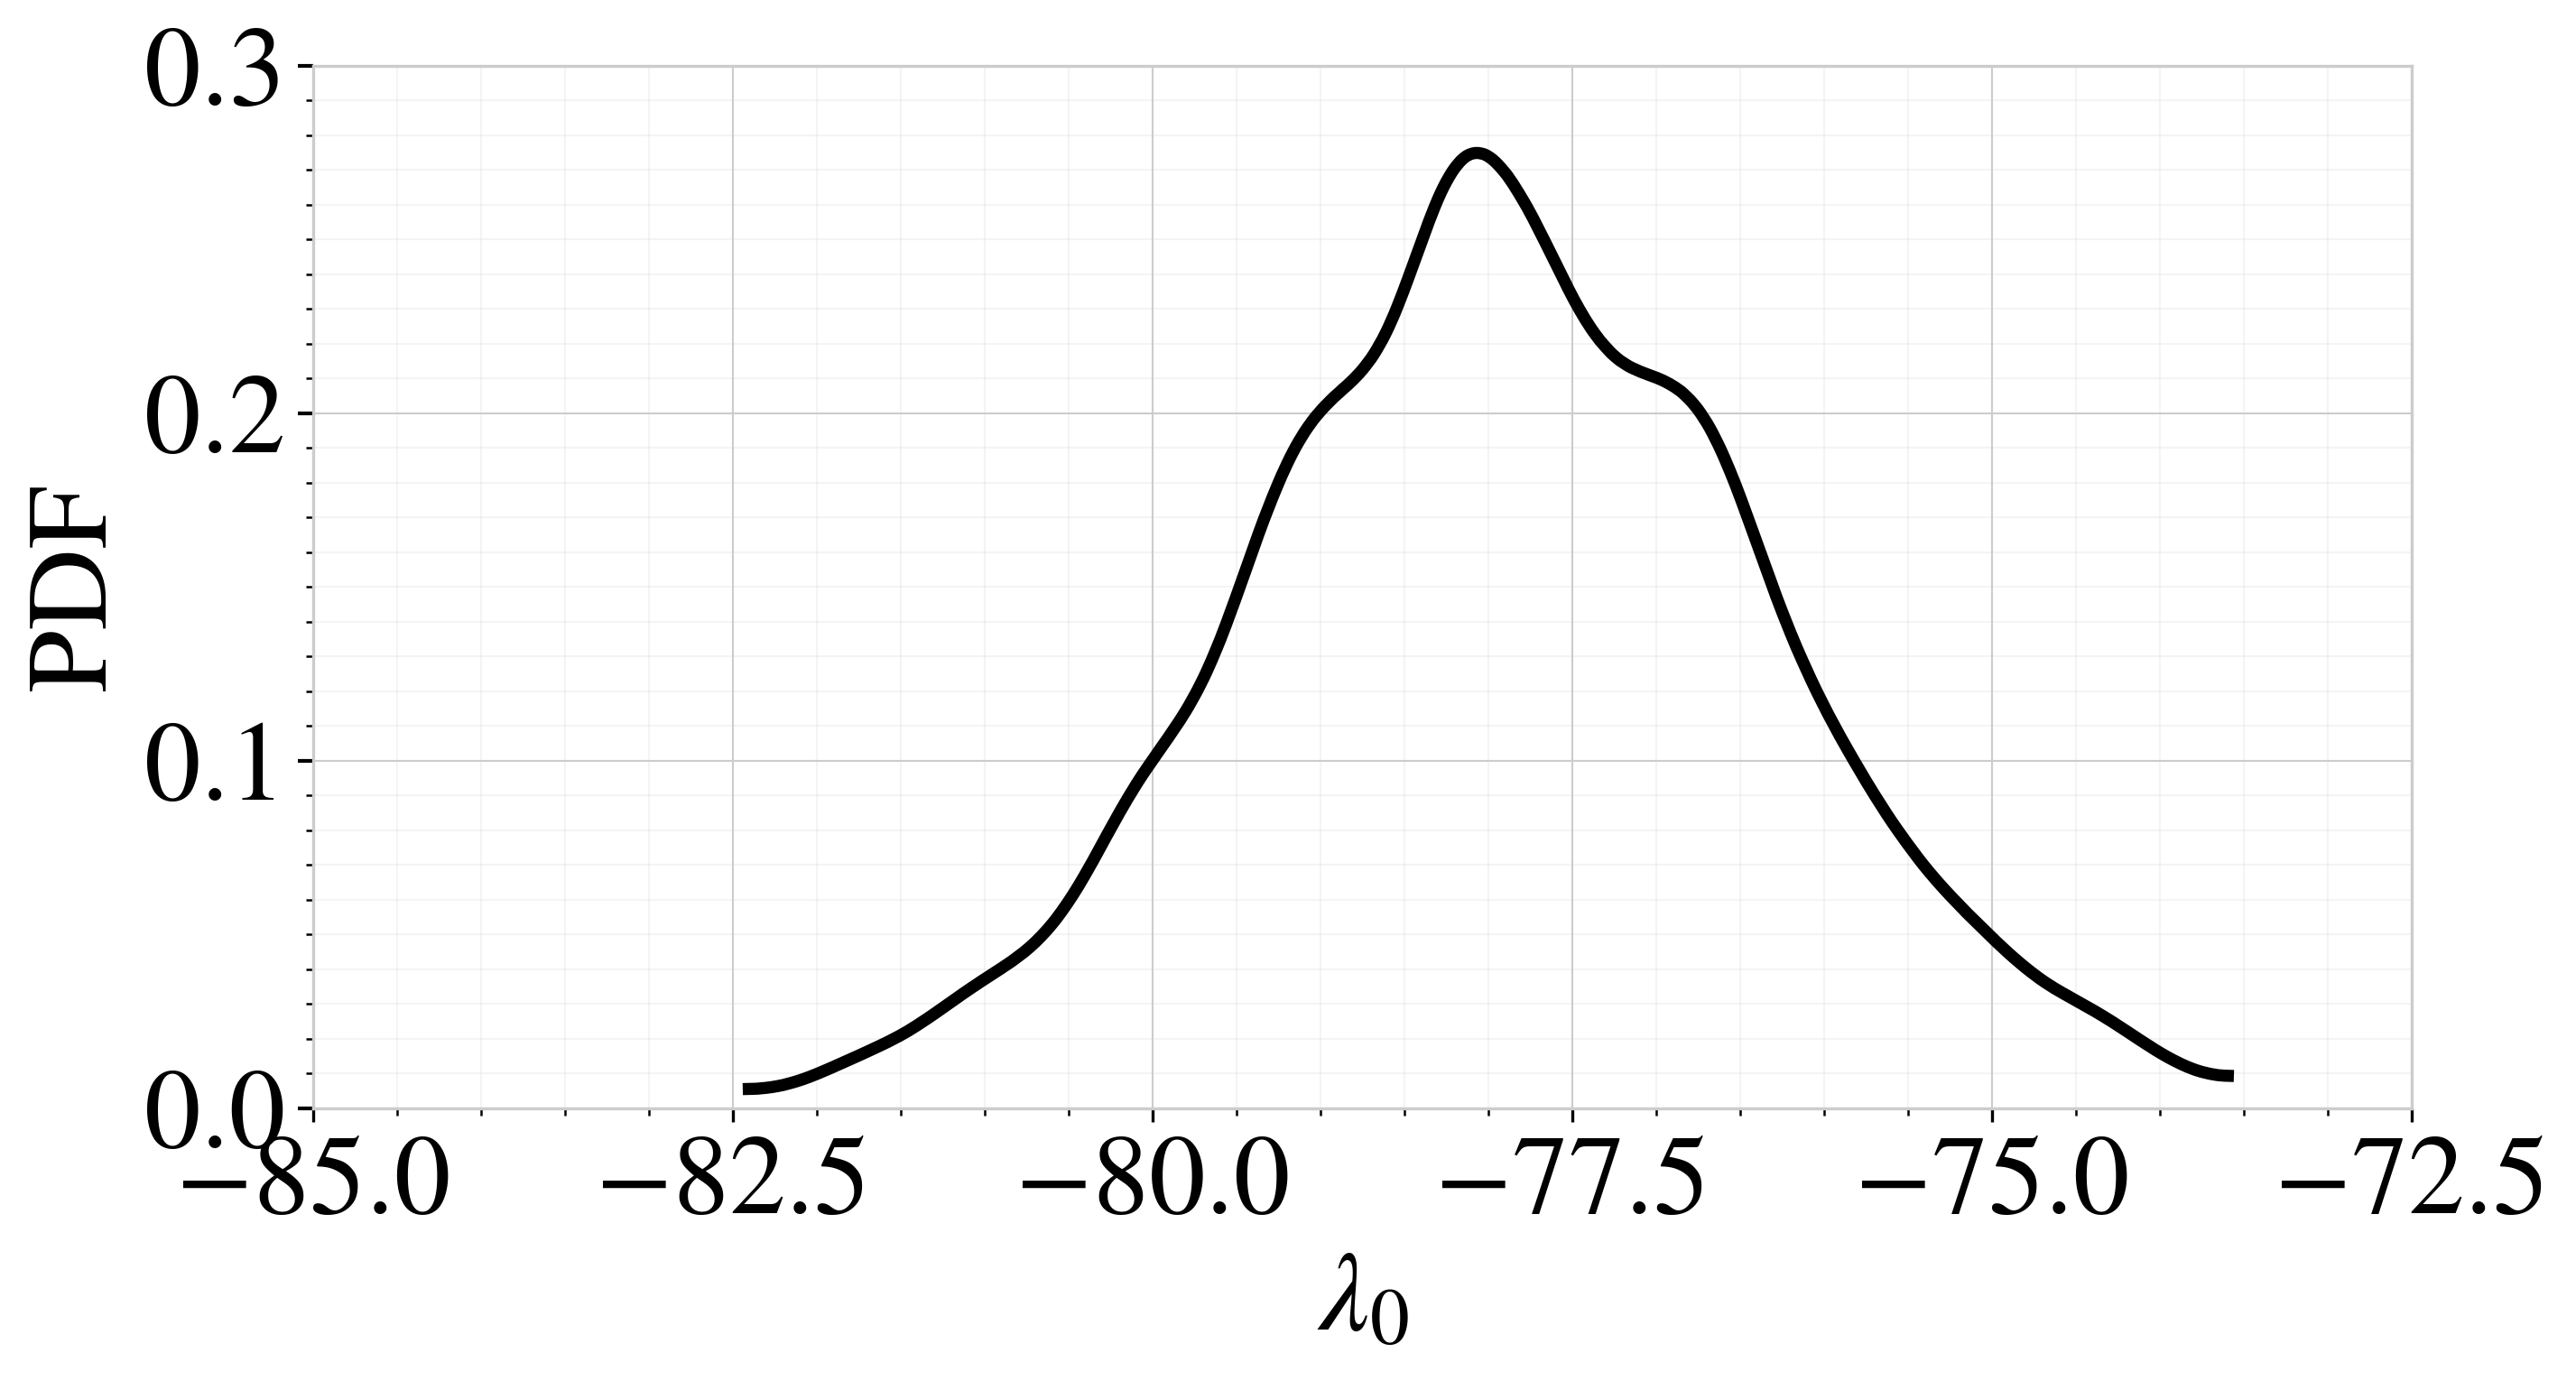

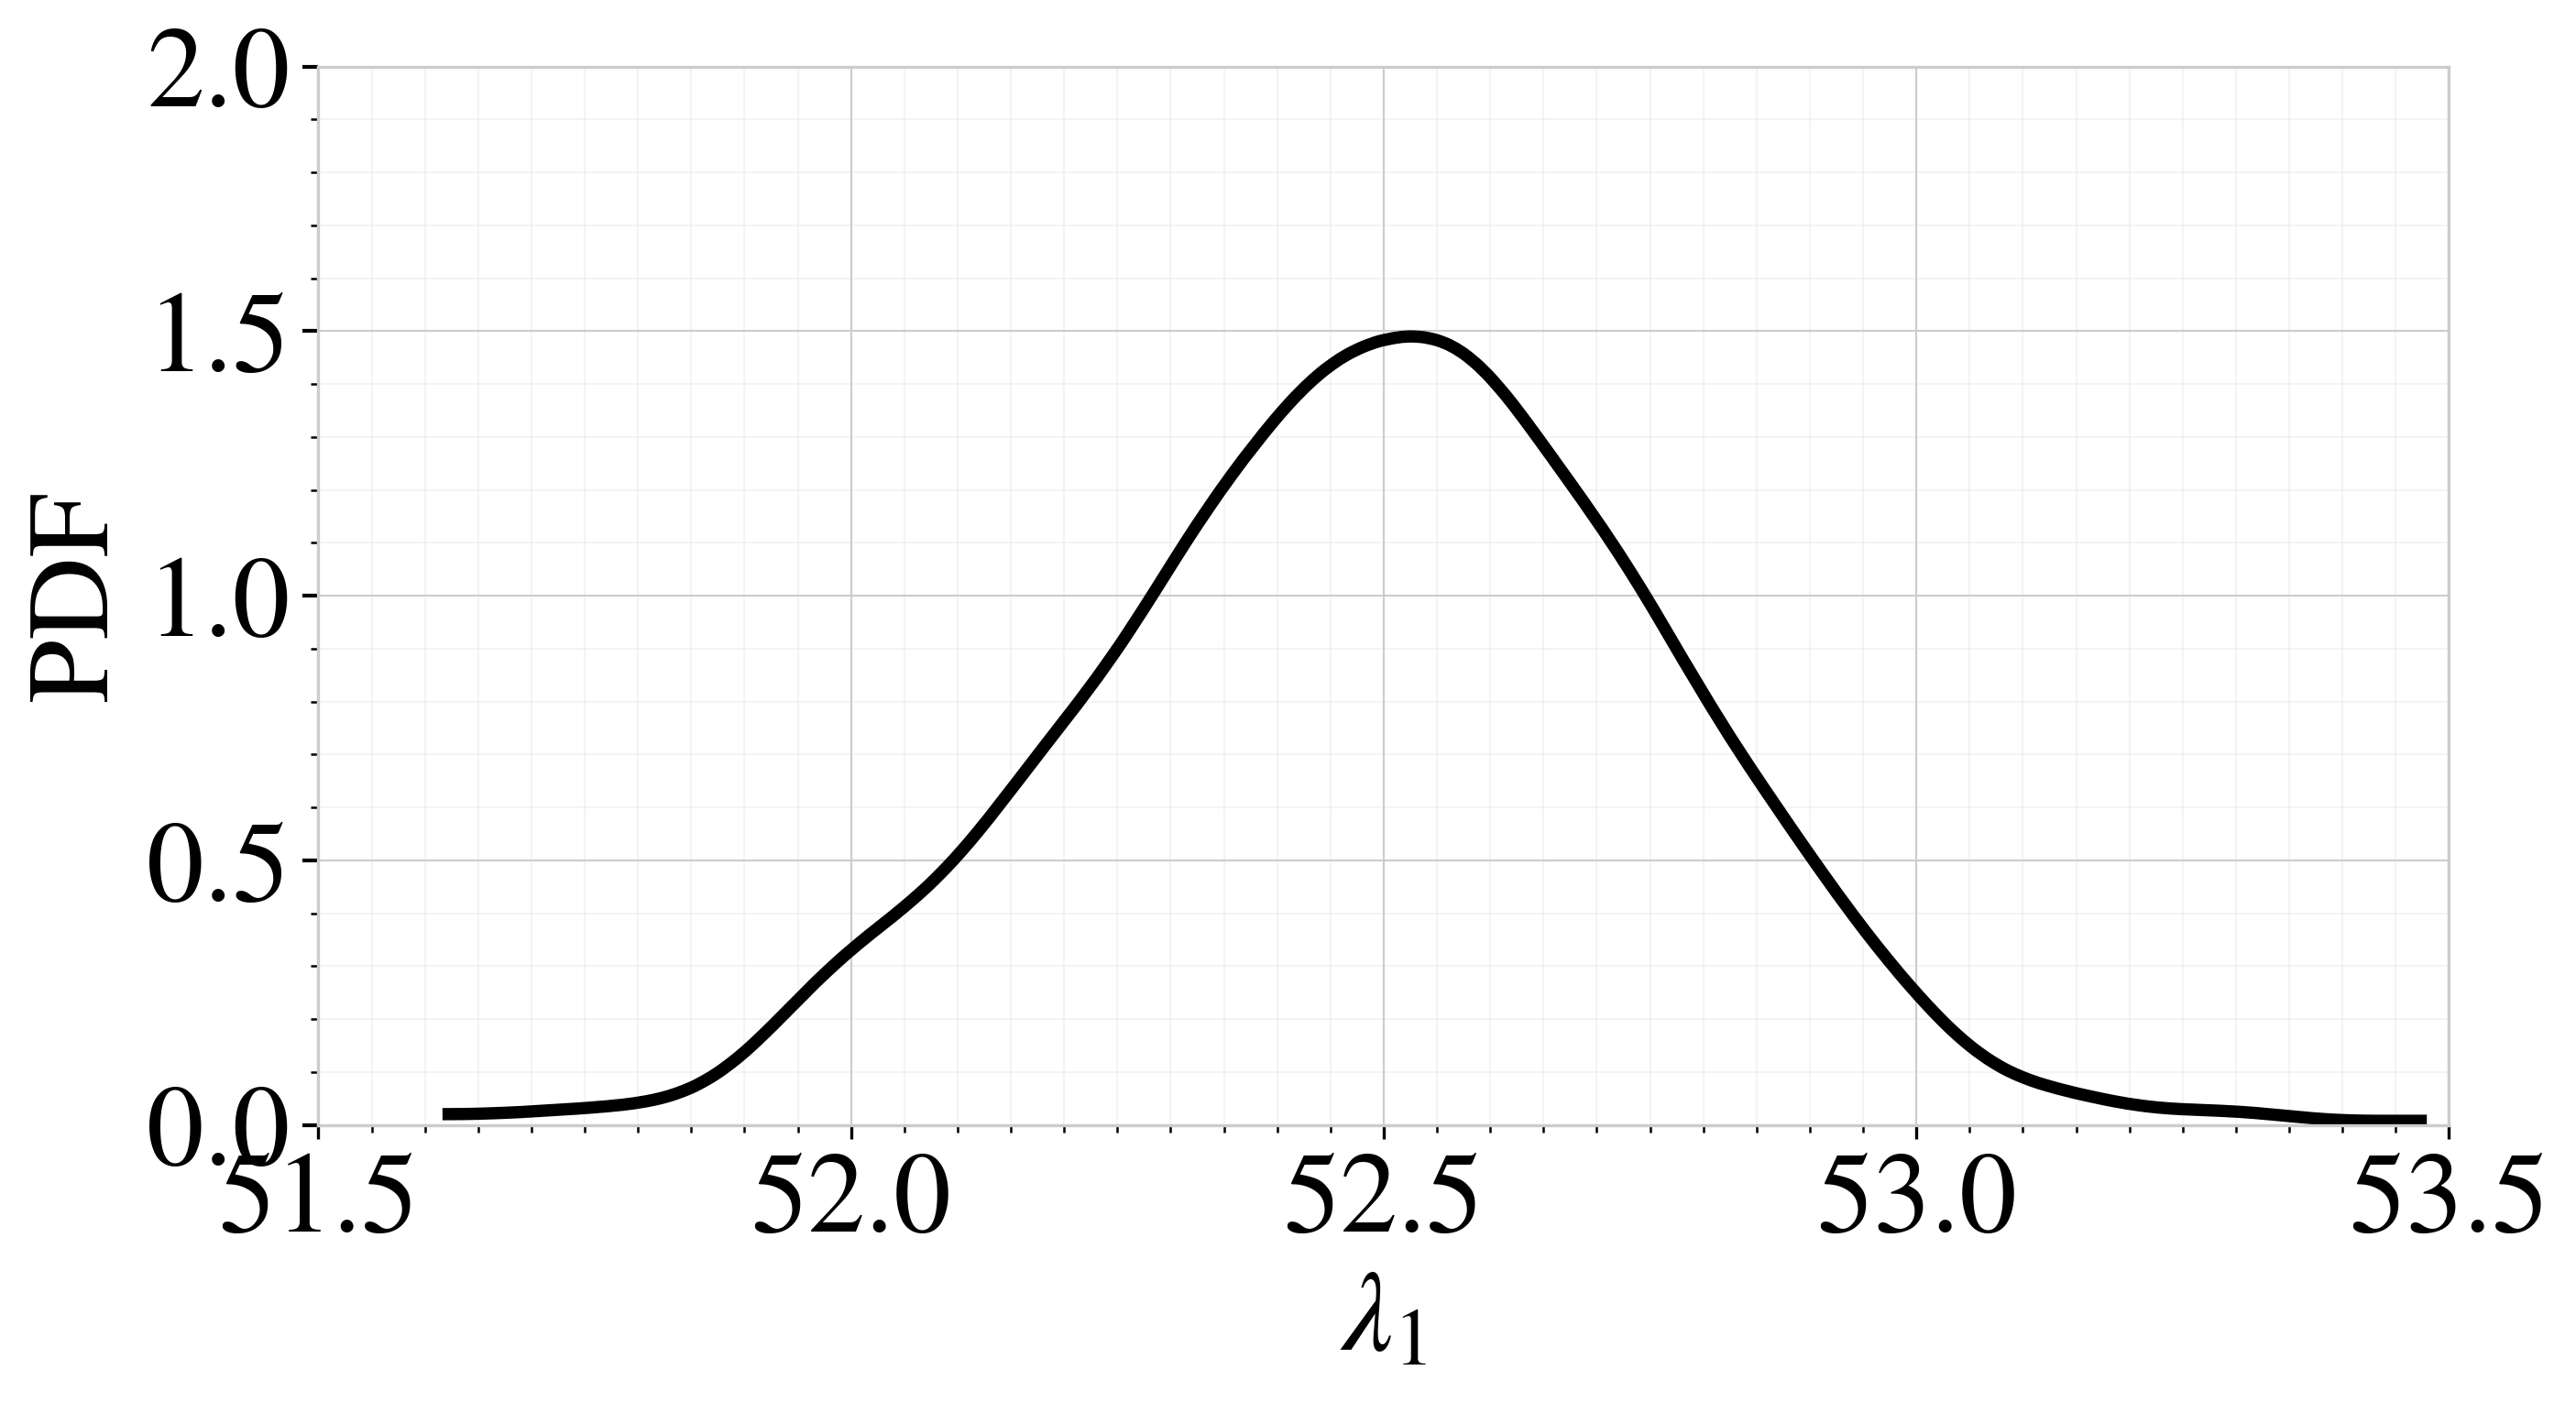

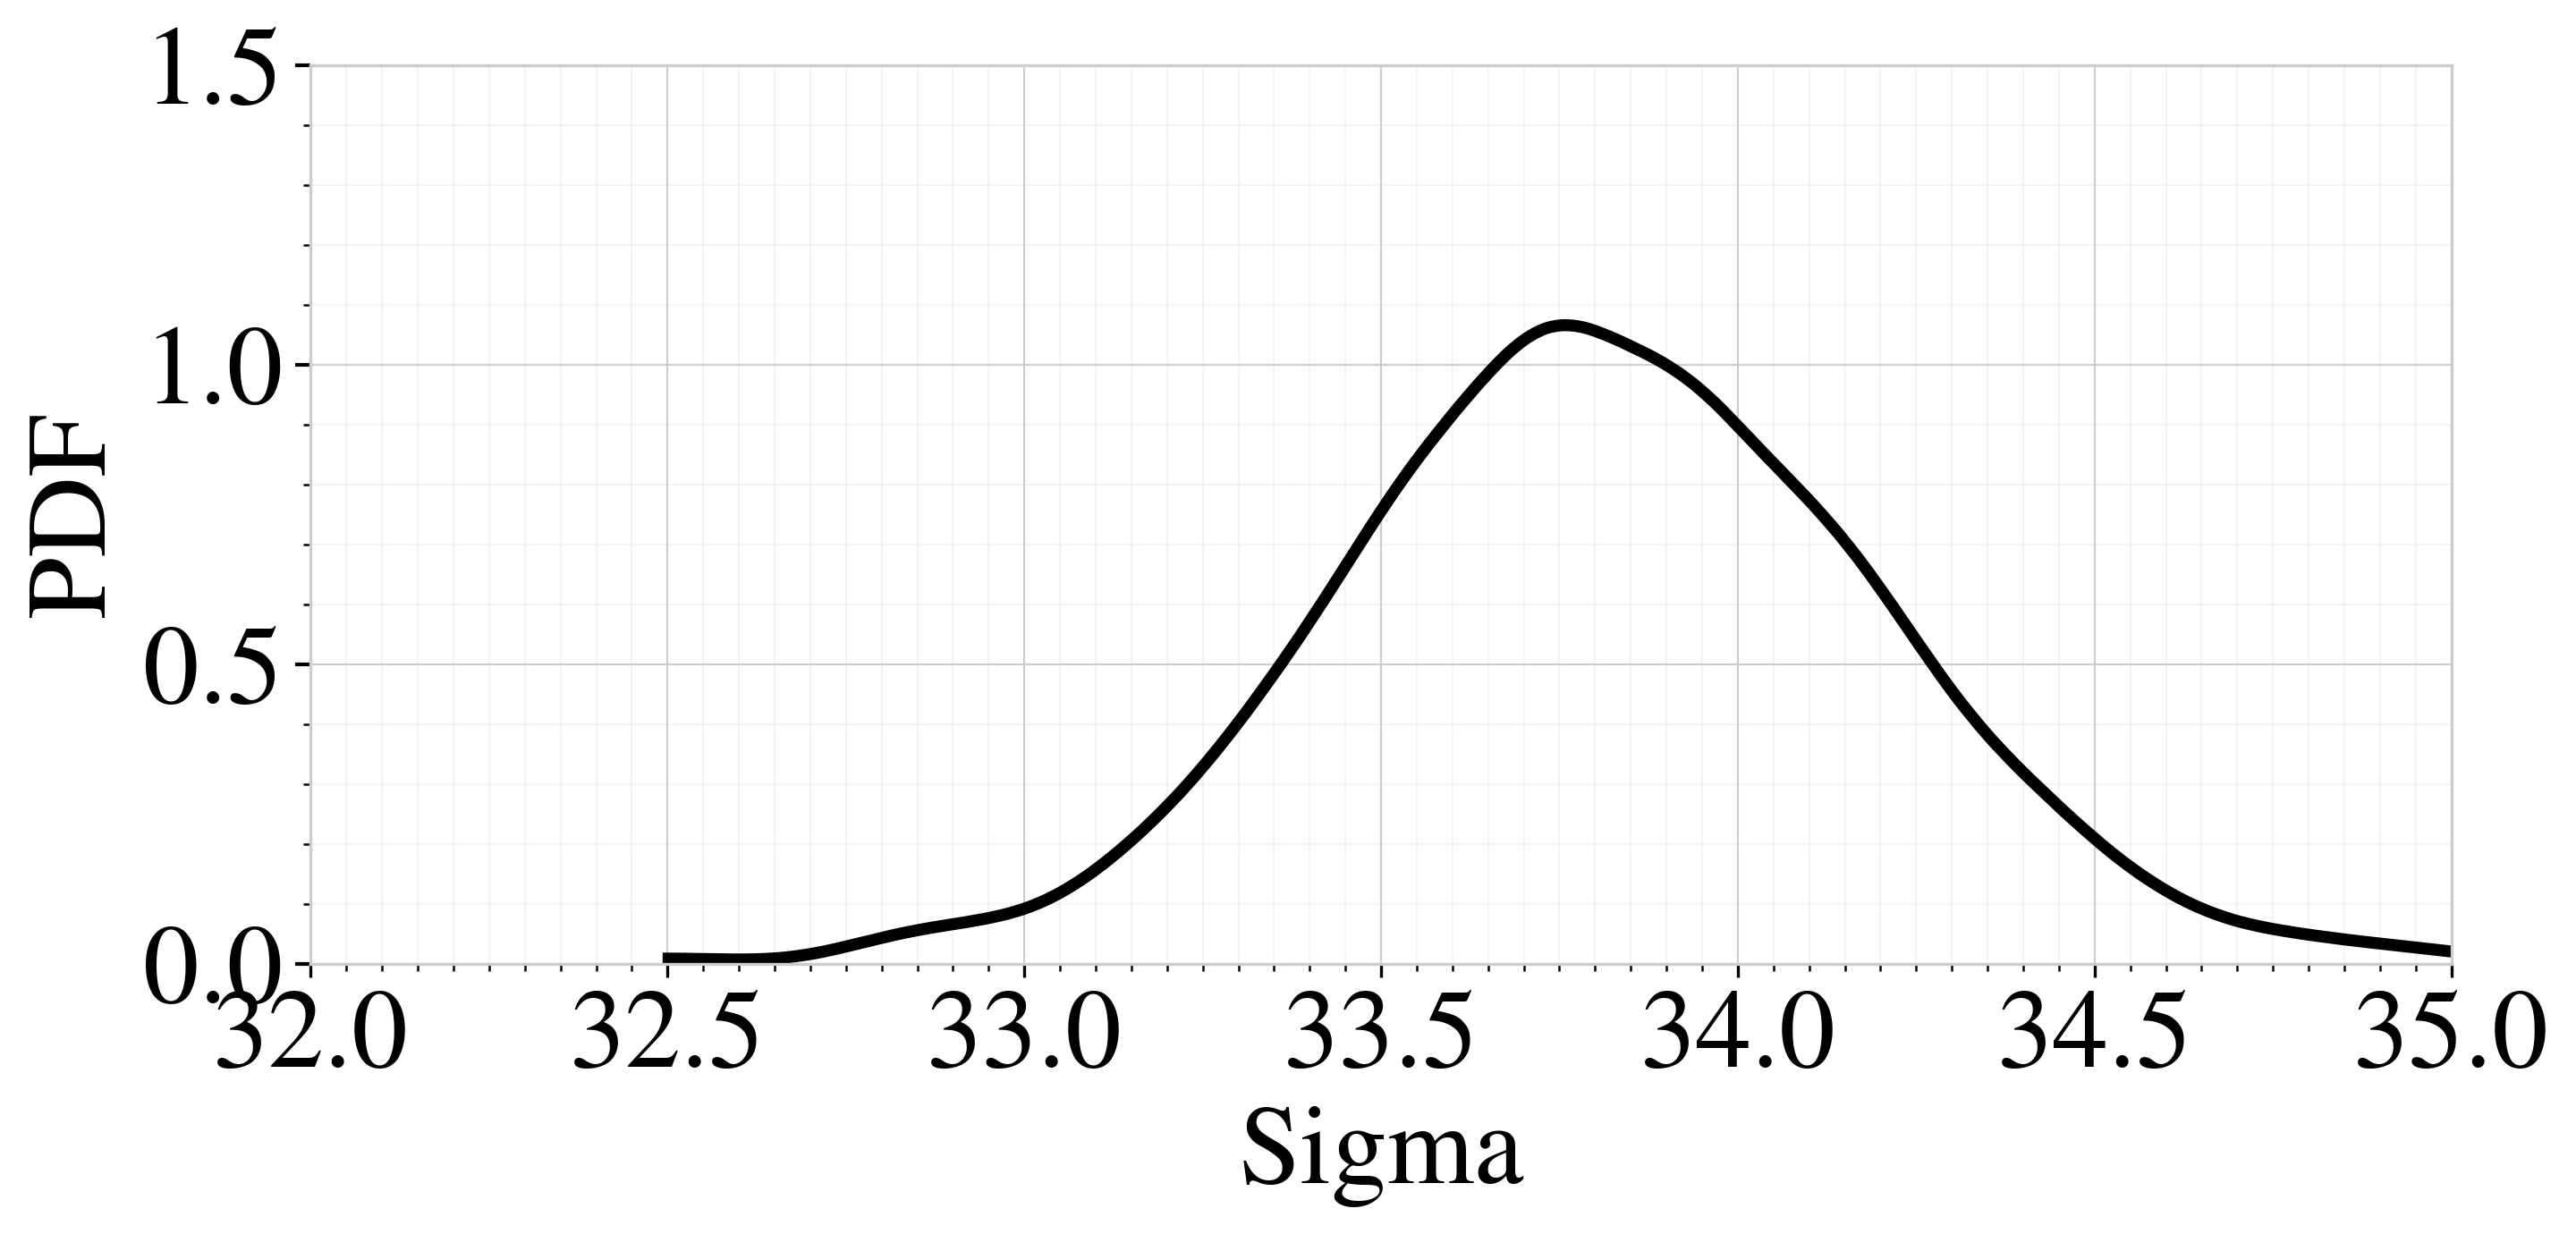

In [ ]:
fig = plt.figure(figsize=(10,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(linear_trace.posterior.intercept[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$\lambda_0$', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([-85, -72.5])
plt.ylim([0, 0.3])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

fig = plt.figure(figsize=(10,5))

ax2 = az.plot_dist(linear_trace.posterior.slope[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$\lambda_1$', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([51.5, 53.5])
plt.ylim([0, 2])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.05))
ax2.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.show()

# # Tercer  subgráfico
# plt.subplot(1, 3, 3)

fig = plt.figure(figsize=(10,5))

ax3 = az.plot_dist(linear_trace.posterior.noise[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('Sigma', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([32, 35])
plt.ylim([0, 1.5])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(MultipleLocator(0.1))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

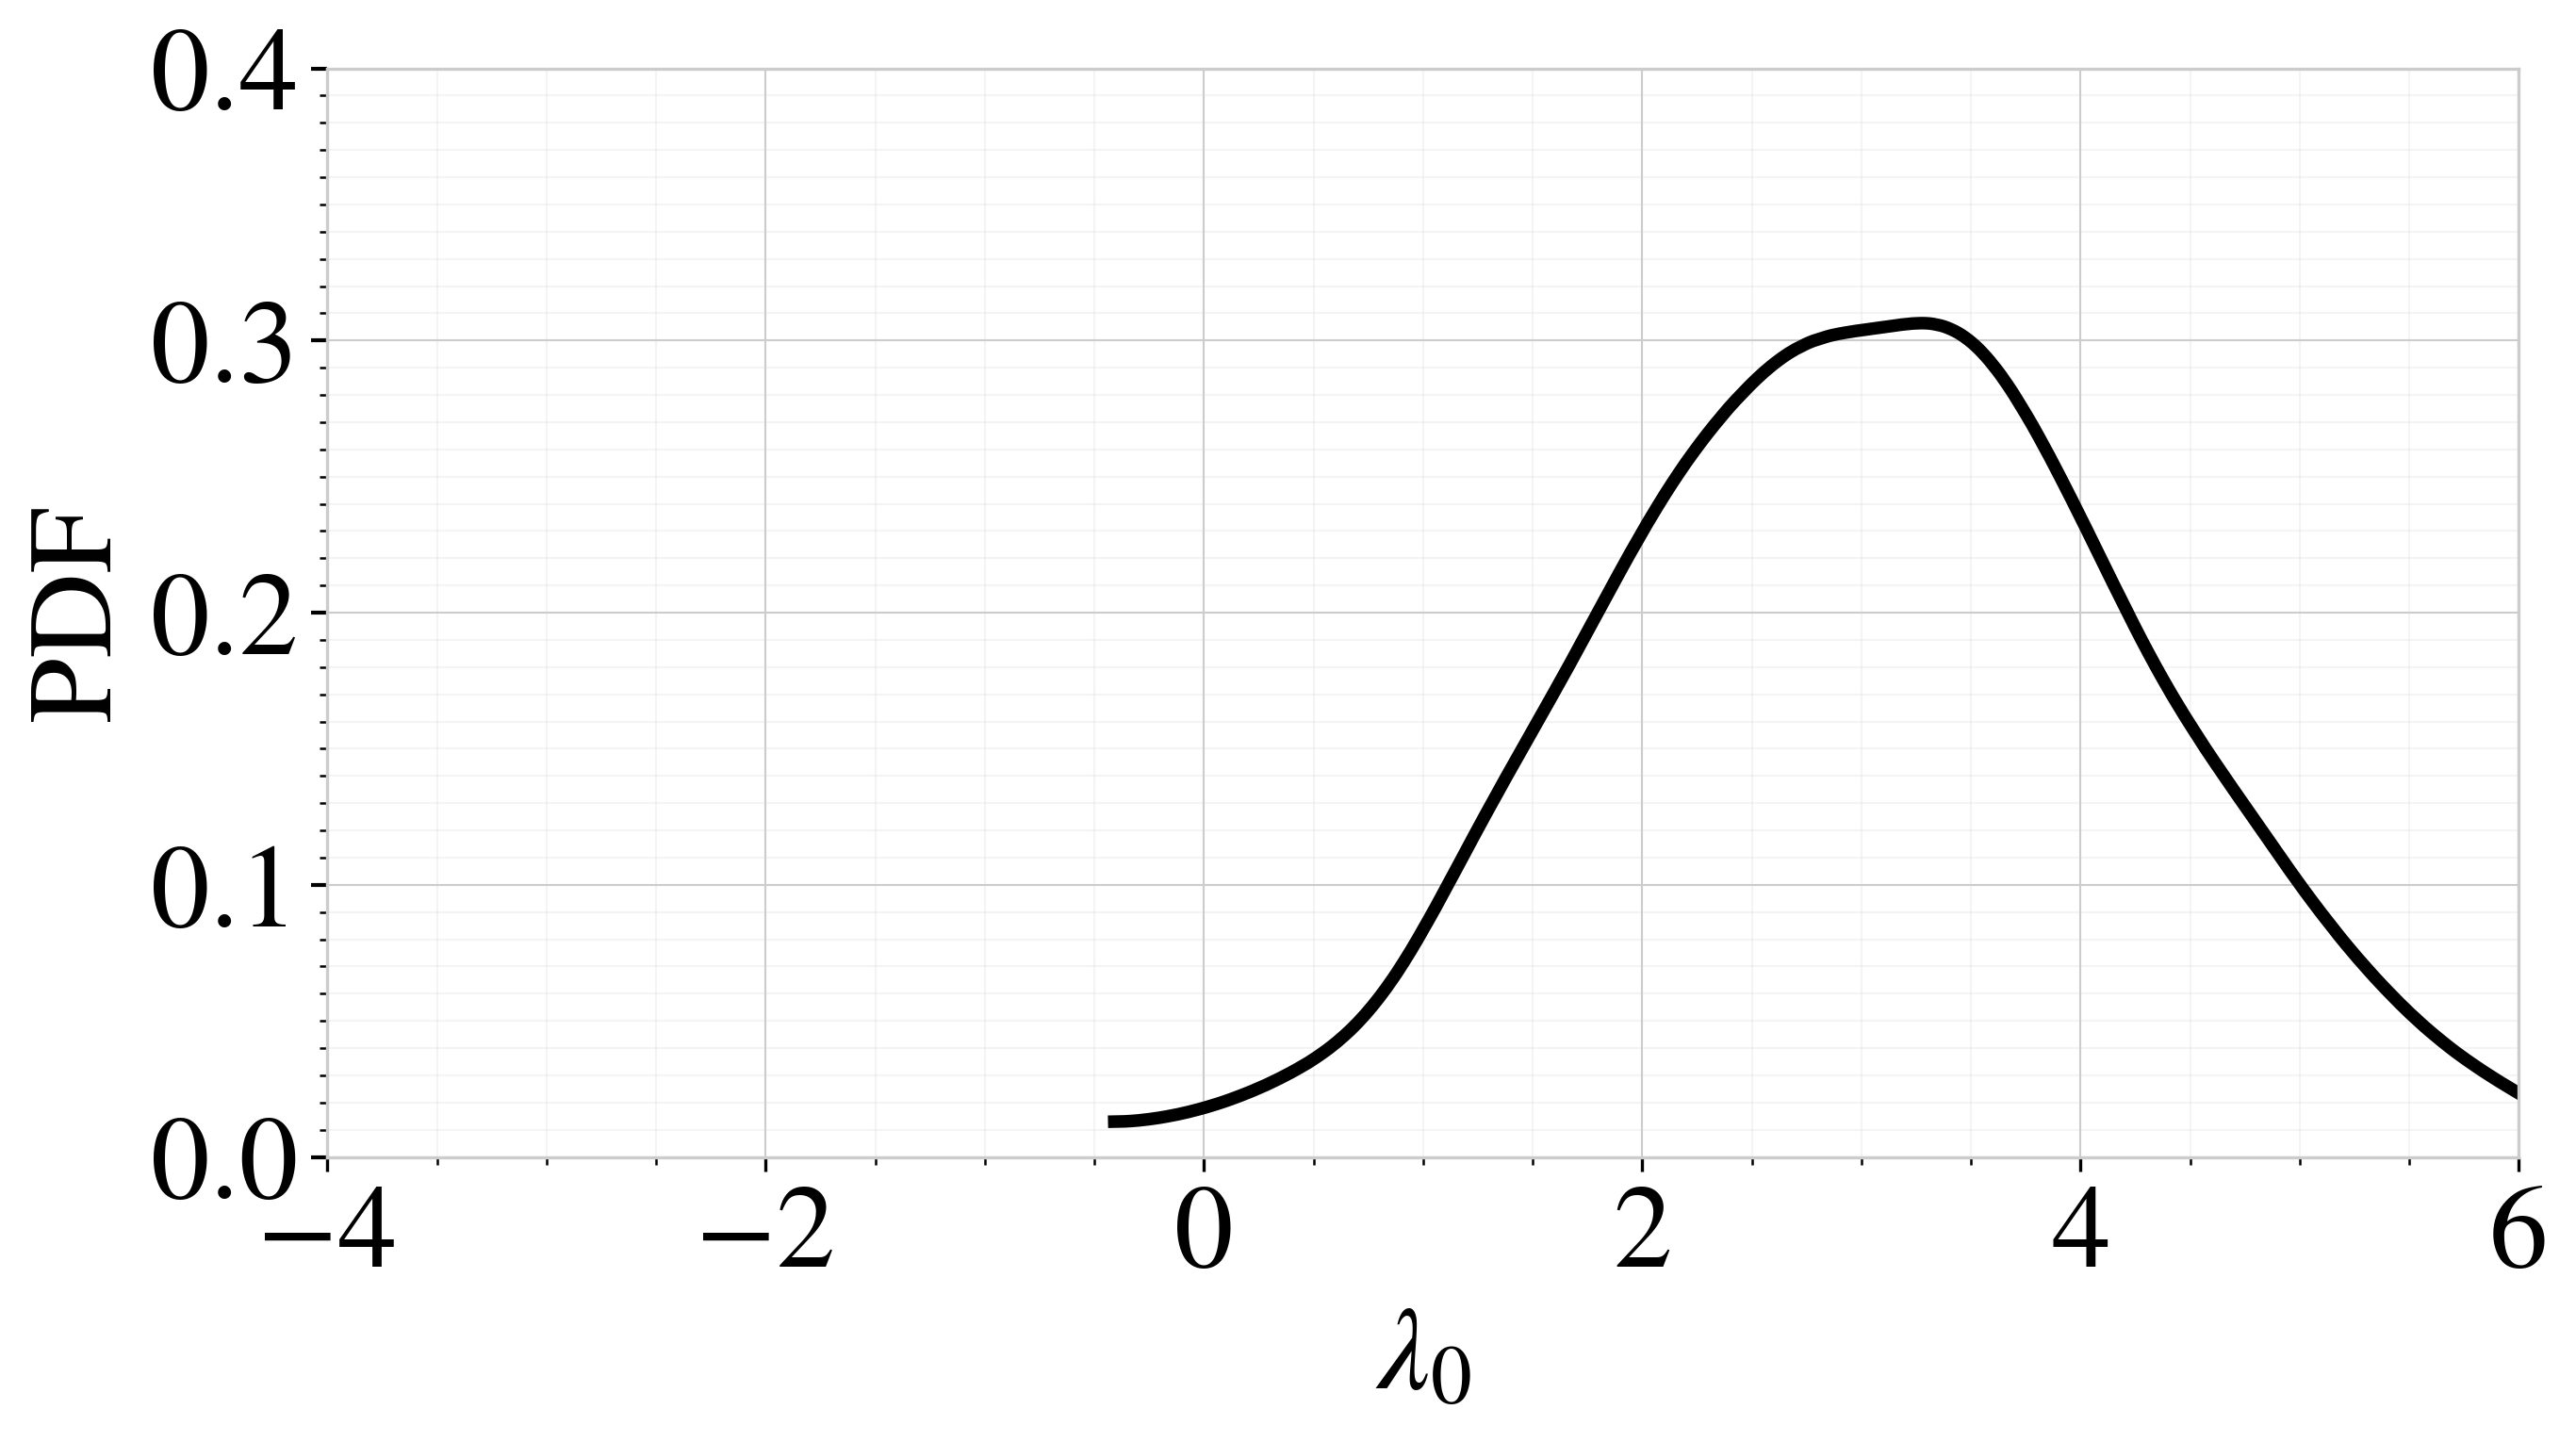

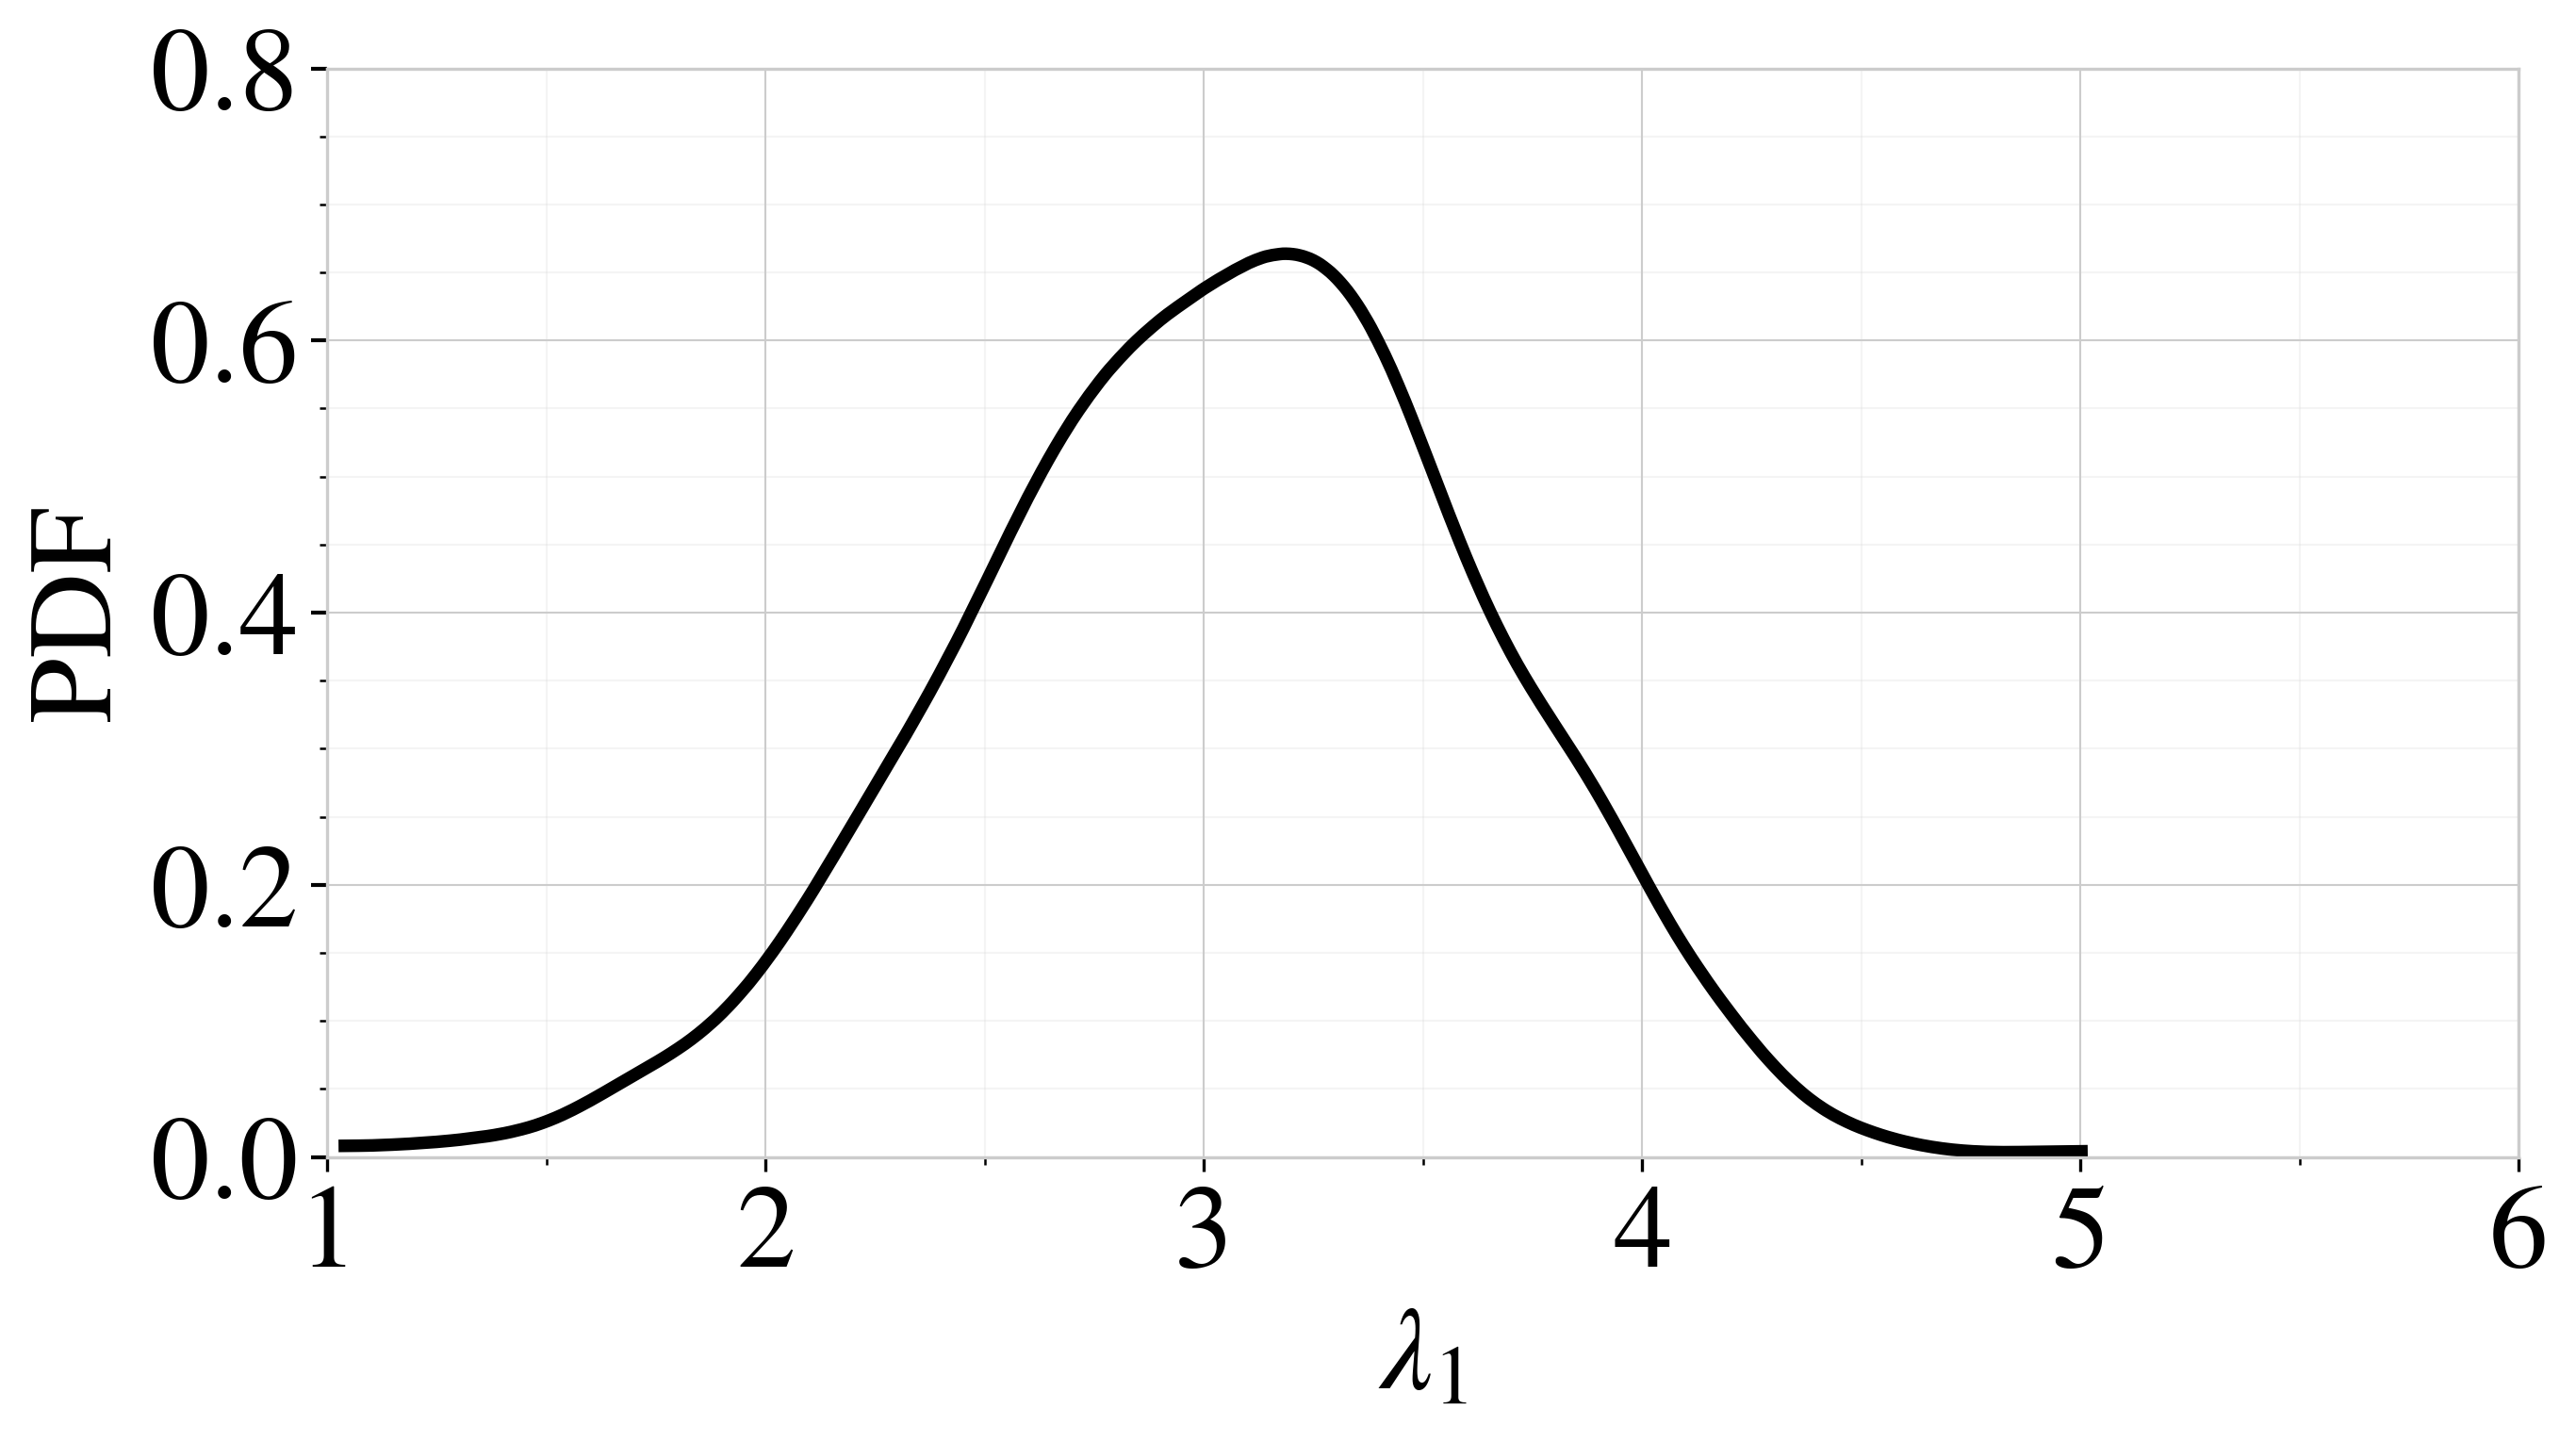

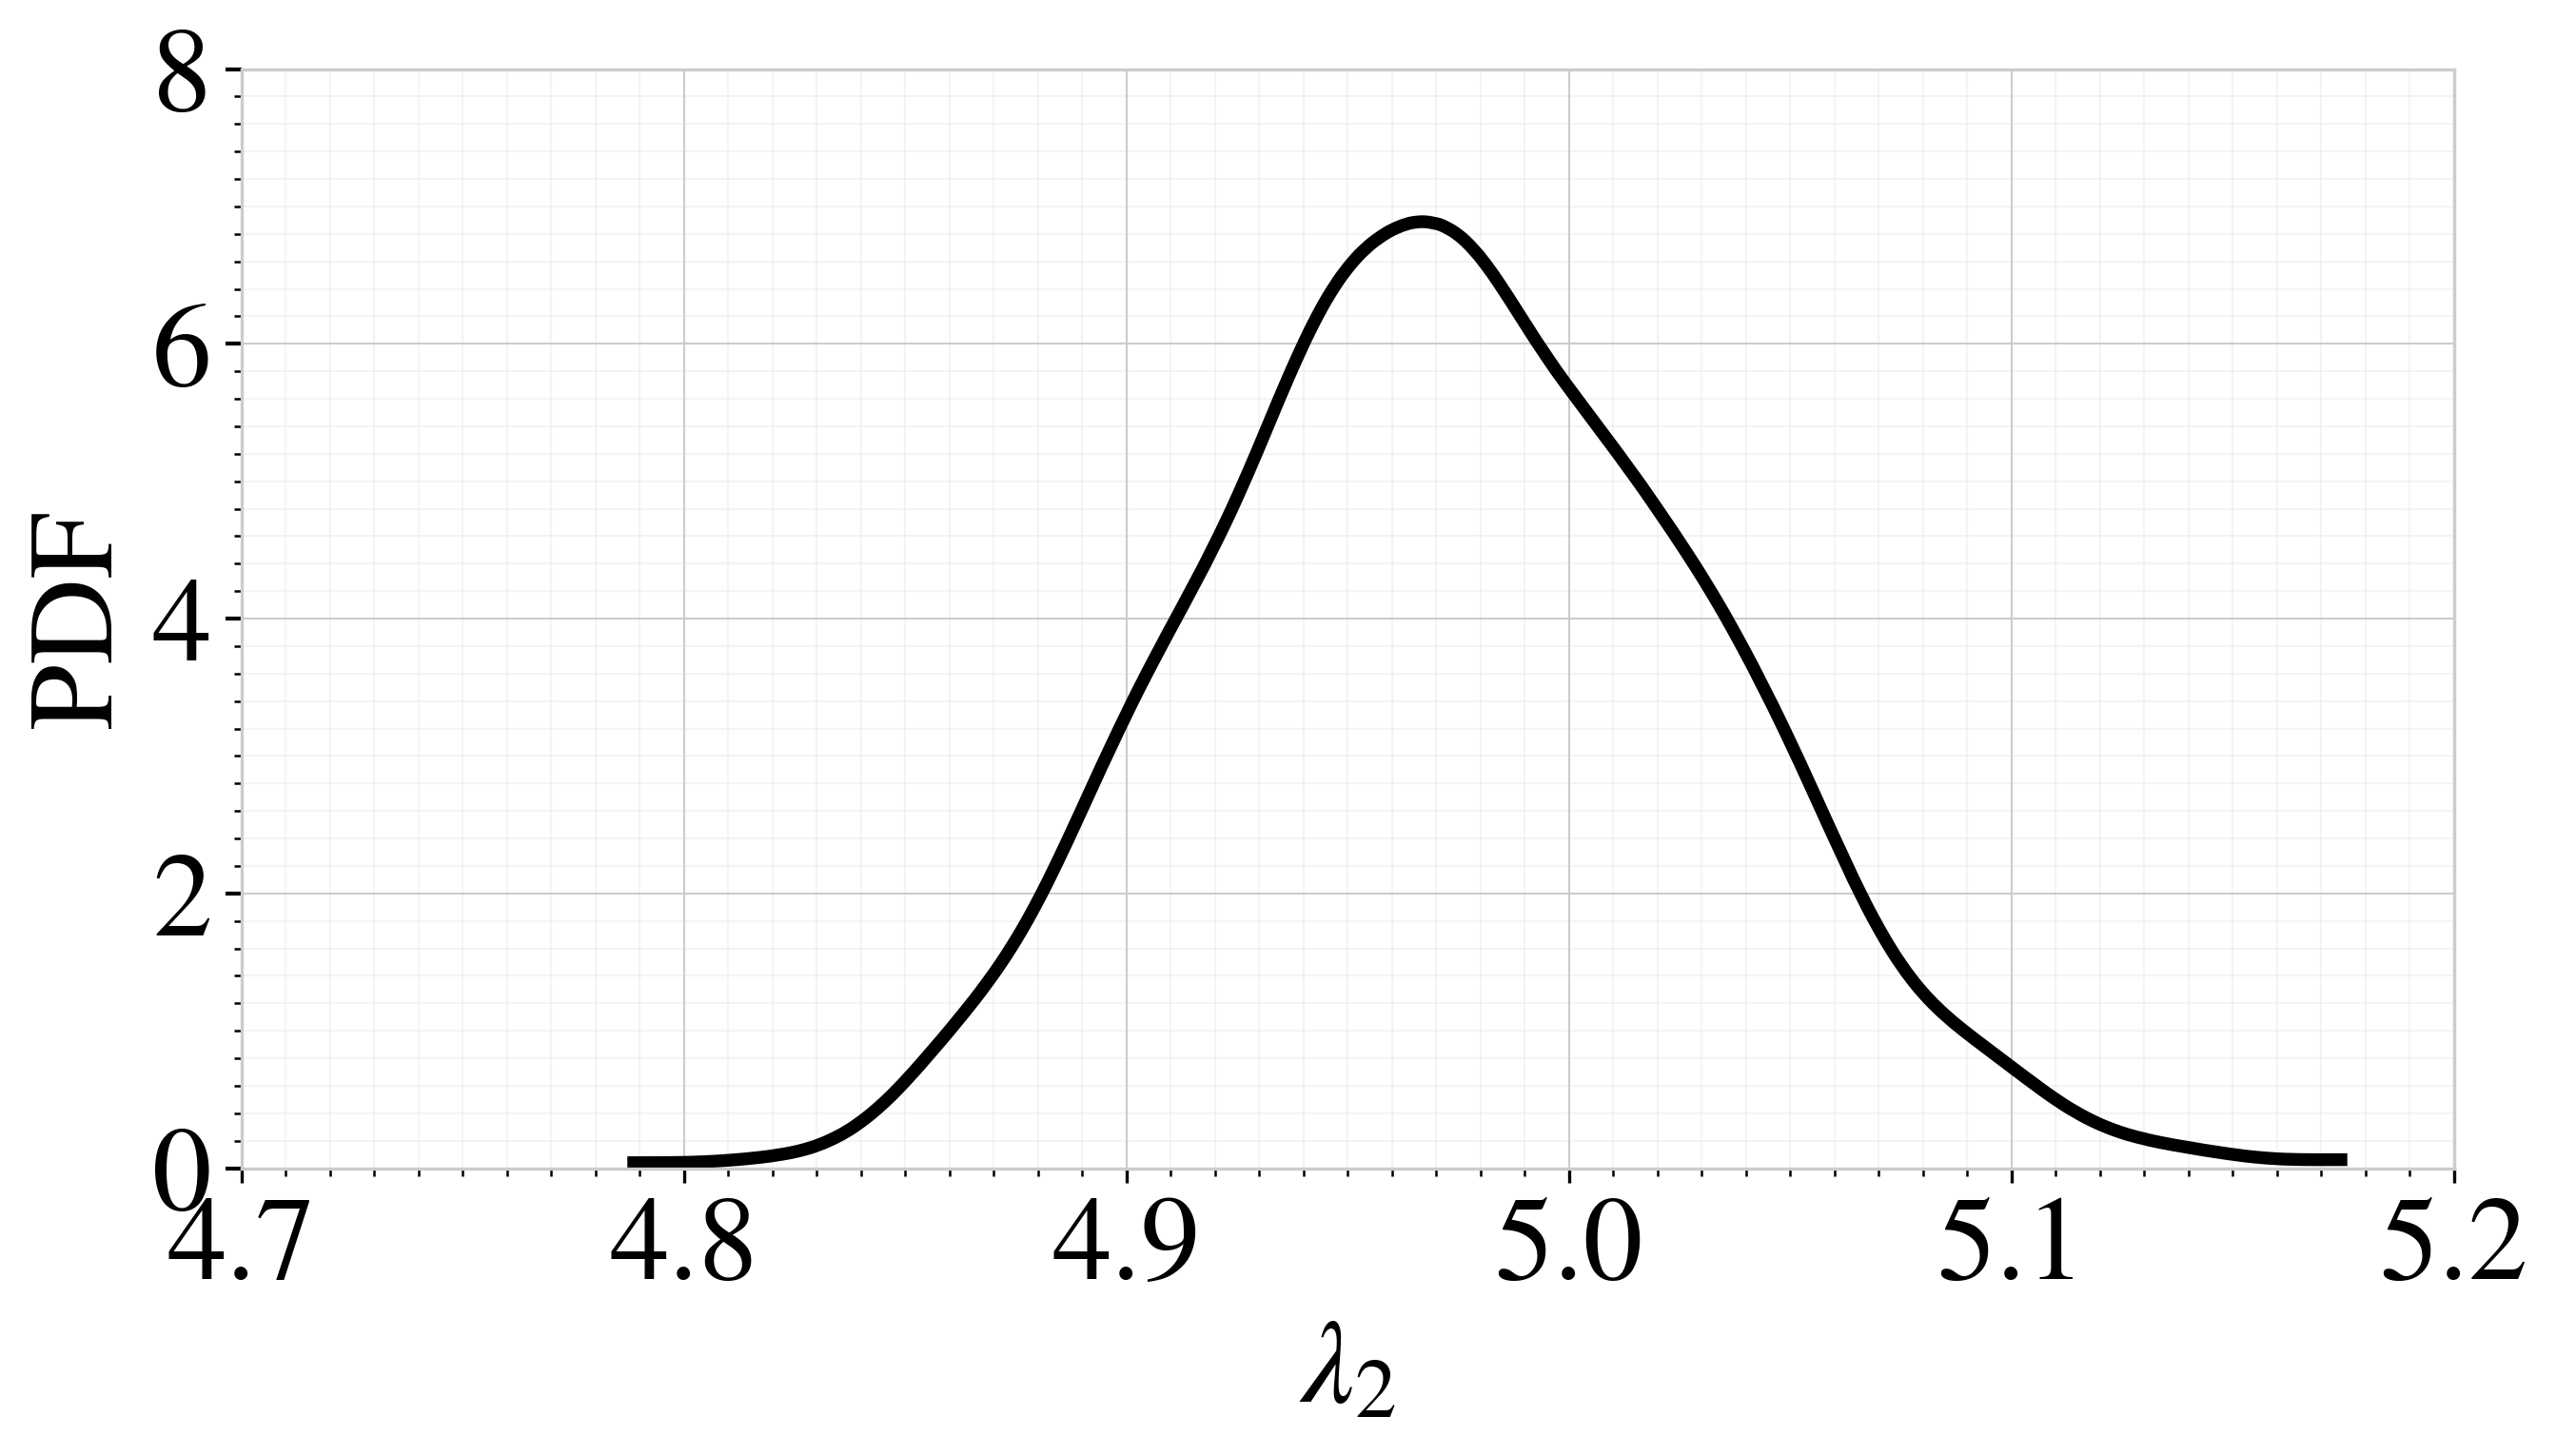

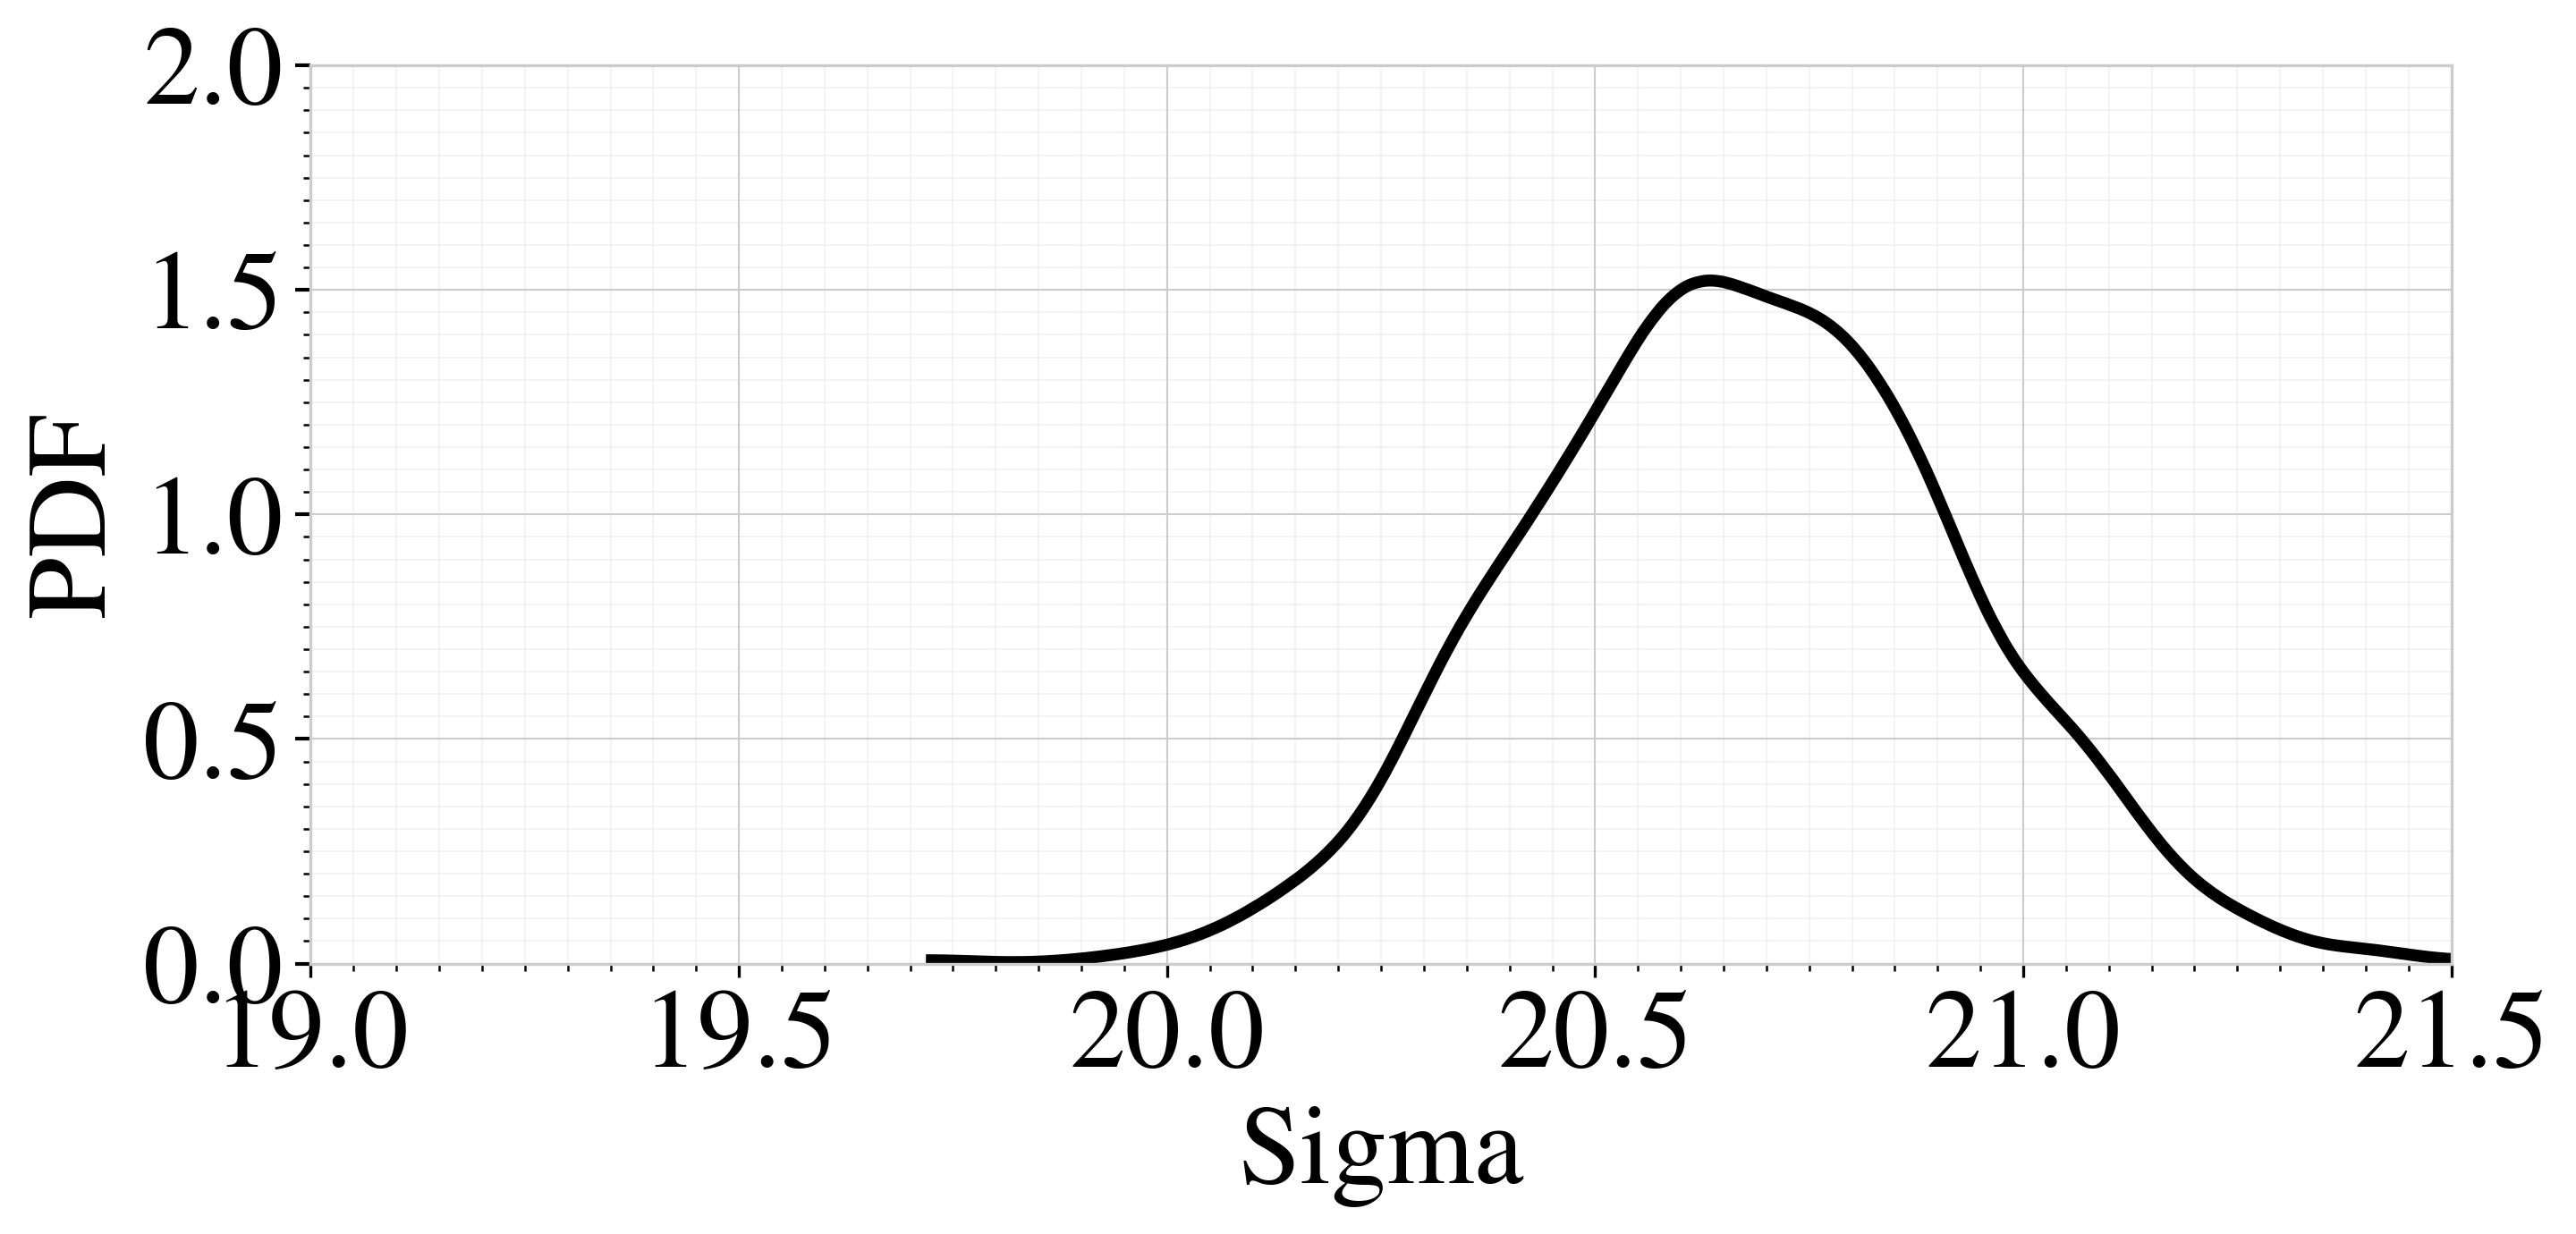

In [ ]:
fig = plt.figure(figsize=(10,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(quad_trace.posterior.intercept[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$\lambda_0$', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([-4, 6])
plt.ylim([0, 0.4])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))
ax1.yaxis.set_minor_locator(MultipleLocator(0.01))

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

fig = plt.figure(figsize=(10,5))

ax2 = az.plot_dist(quad_trace.posterior.slope[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$\lambda_1$', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([1, 6])
plt.ylim([0, 0.8])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.5))
ax2.yaxis.set_minor_locator(MultipleLocator(0.05))

# plt.show()

# # Tercer subgráfico
# plt.subplot(1, 3, 2)

fig = plt.figure(figsize=(10,5))

ax2 = az.plot_dist(quad_trace.posterior.quad_coeff[0], rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('$\lambda_2$', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([4.70, 5.20])
plt.ylim([0, 8])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.01))
ax2.yaxis.set_minor_locator(MultipleLocator(0.2))

plt.show()


# # Cuatro  subgráfico
# plt.subplot(1, 3, 3)

fig = plt.figure(figsize=(10,5))

ax3 = az.plot_dist(quad_trace.posterior.noise[0]+1.8, rug=True, color='k', textsize=30)
# plt.title('Taylor Series of degree 3')
plt.xlabel('Sigma', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([19, 21.5])
plt.ylim([0, 2])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(MultipleLocator(0.05))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

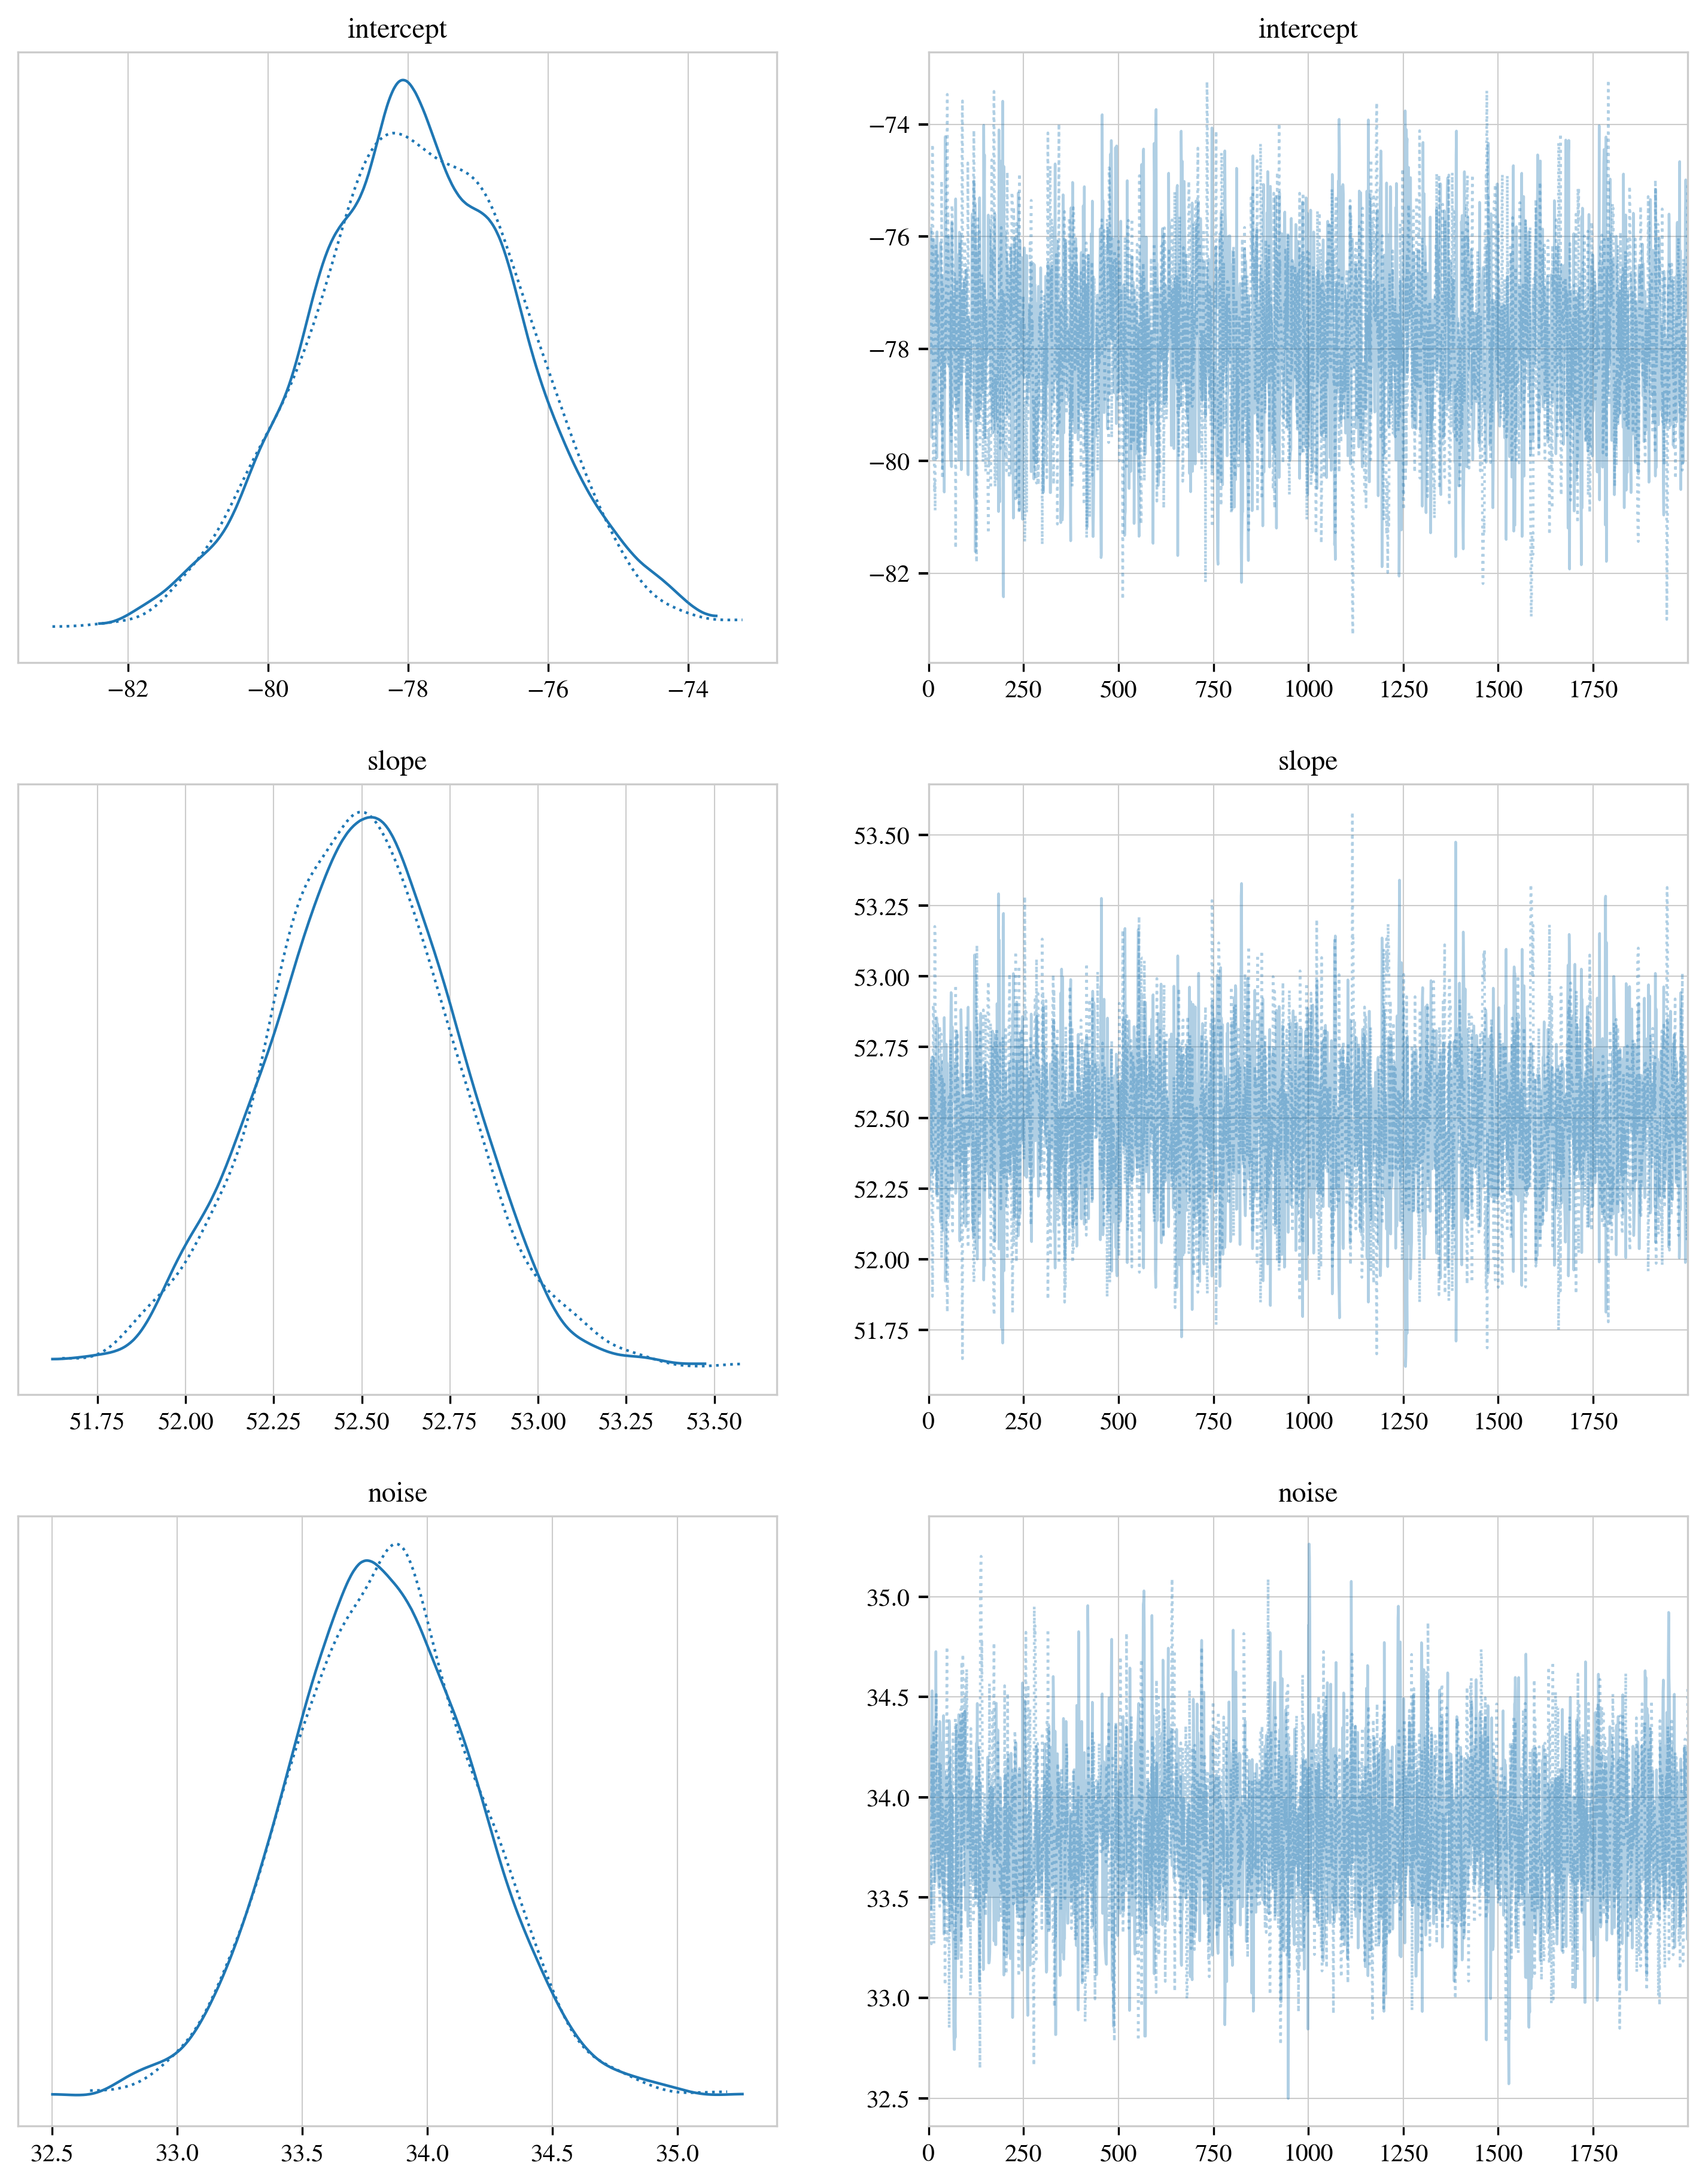

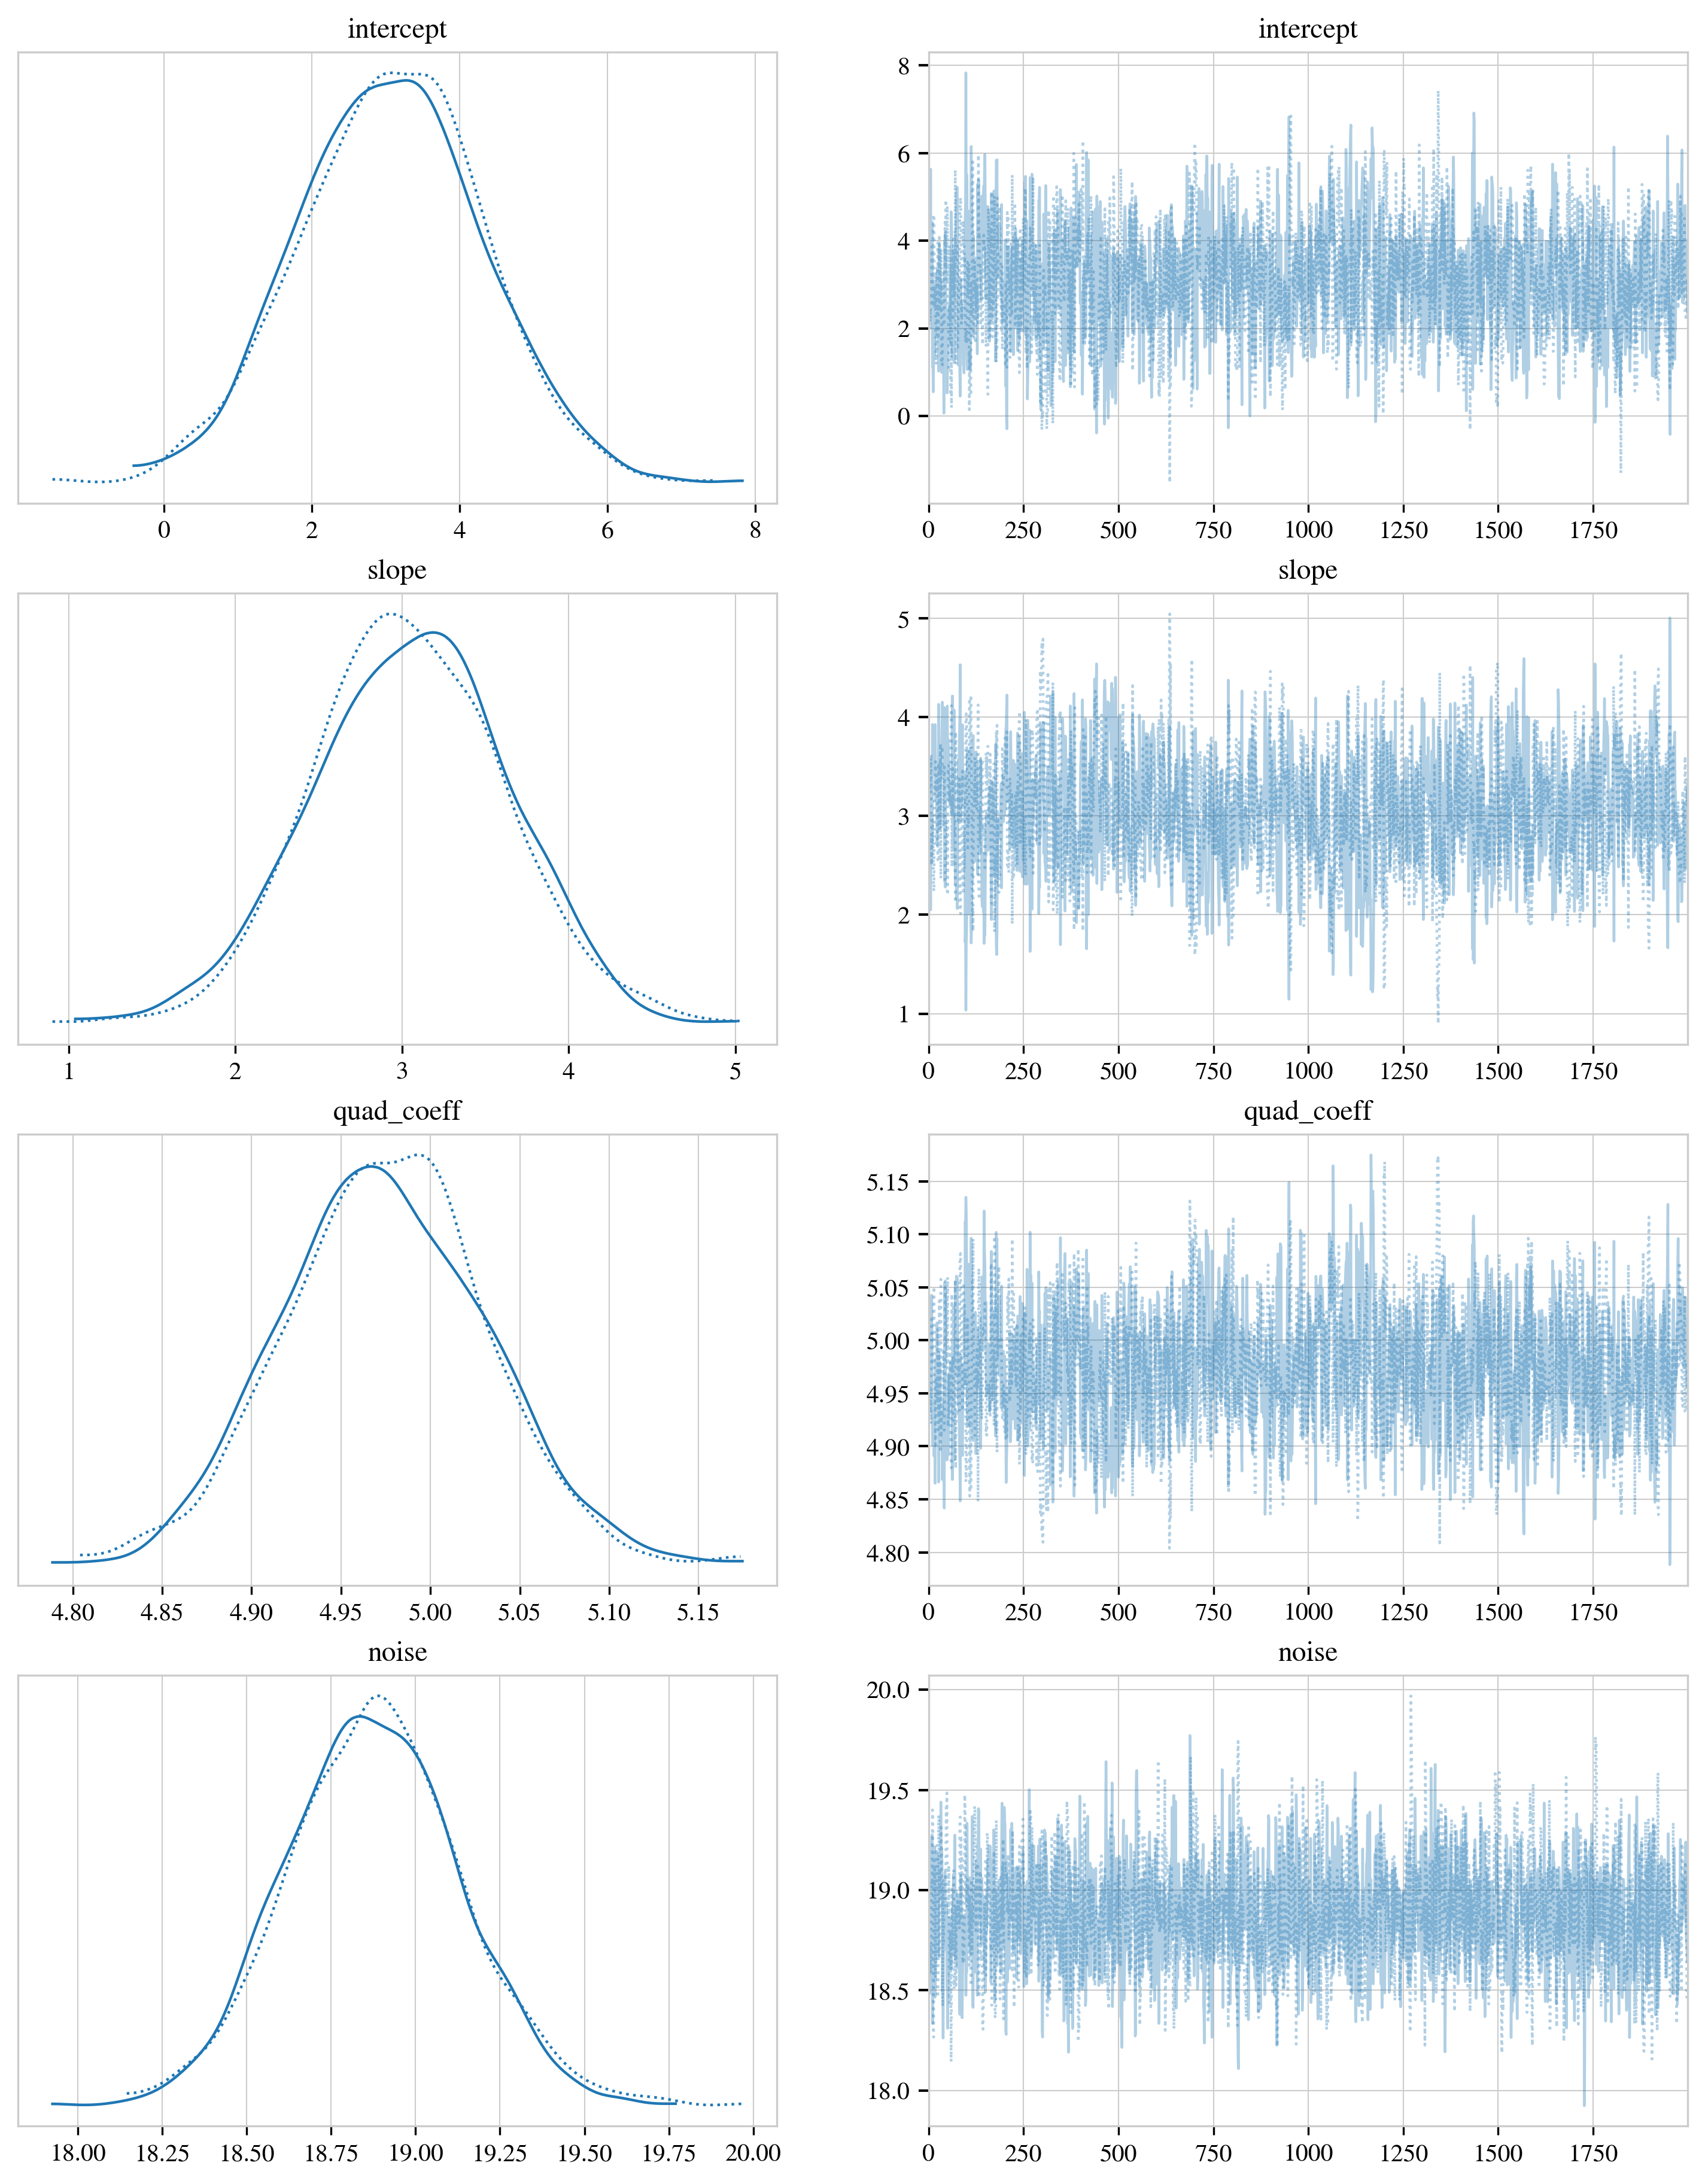

In [ ]:
# Posterior check distribution
pm.plot_trace(linear_trace, var_names=['intercept', 'slope', 'noise'], figsize=(12, 15))
plt.show()

pm.plot_trace(quad_trace, var_names=['intercept', 'slope', 'quad_coeff', 'noise'], figsize=(12, 15))
plt.show()

In [ ]:
# Generate new data using the parameters of the updated models.
with linear_model:
    post_pred_linear = pm.sample_posterior_predictive(linear_trace)

with quad_model:
    post_pred_quad = pm.sample_posterior_predictive(quad_trace)

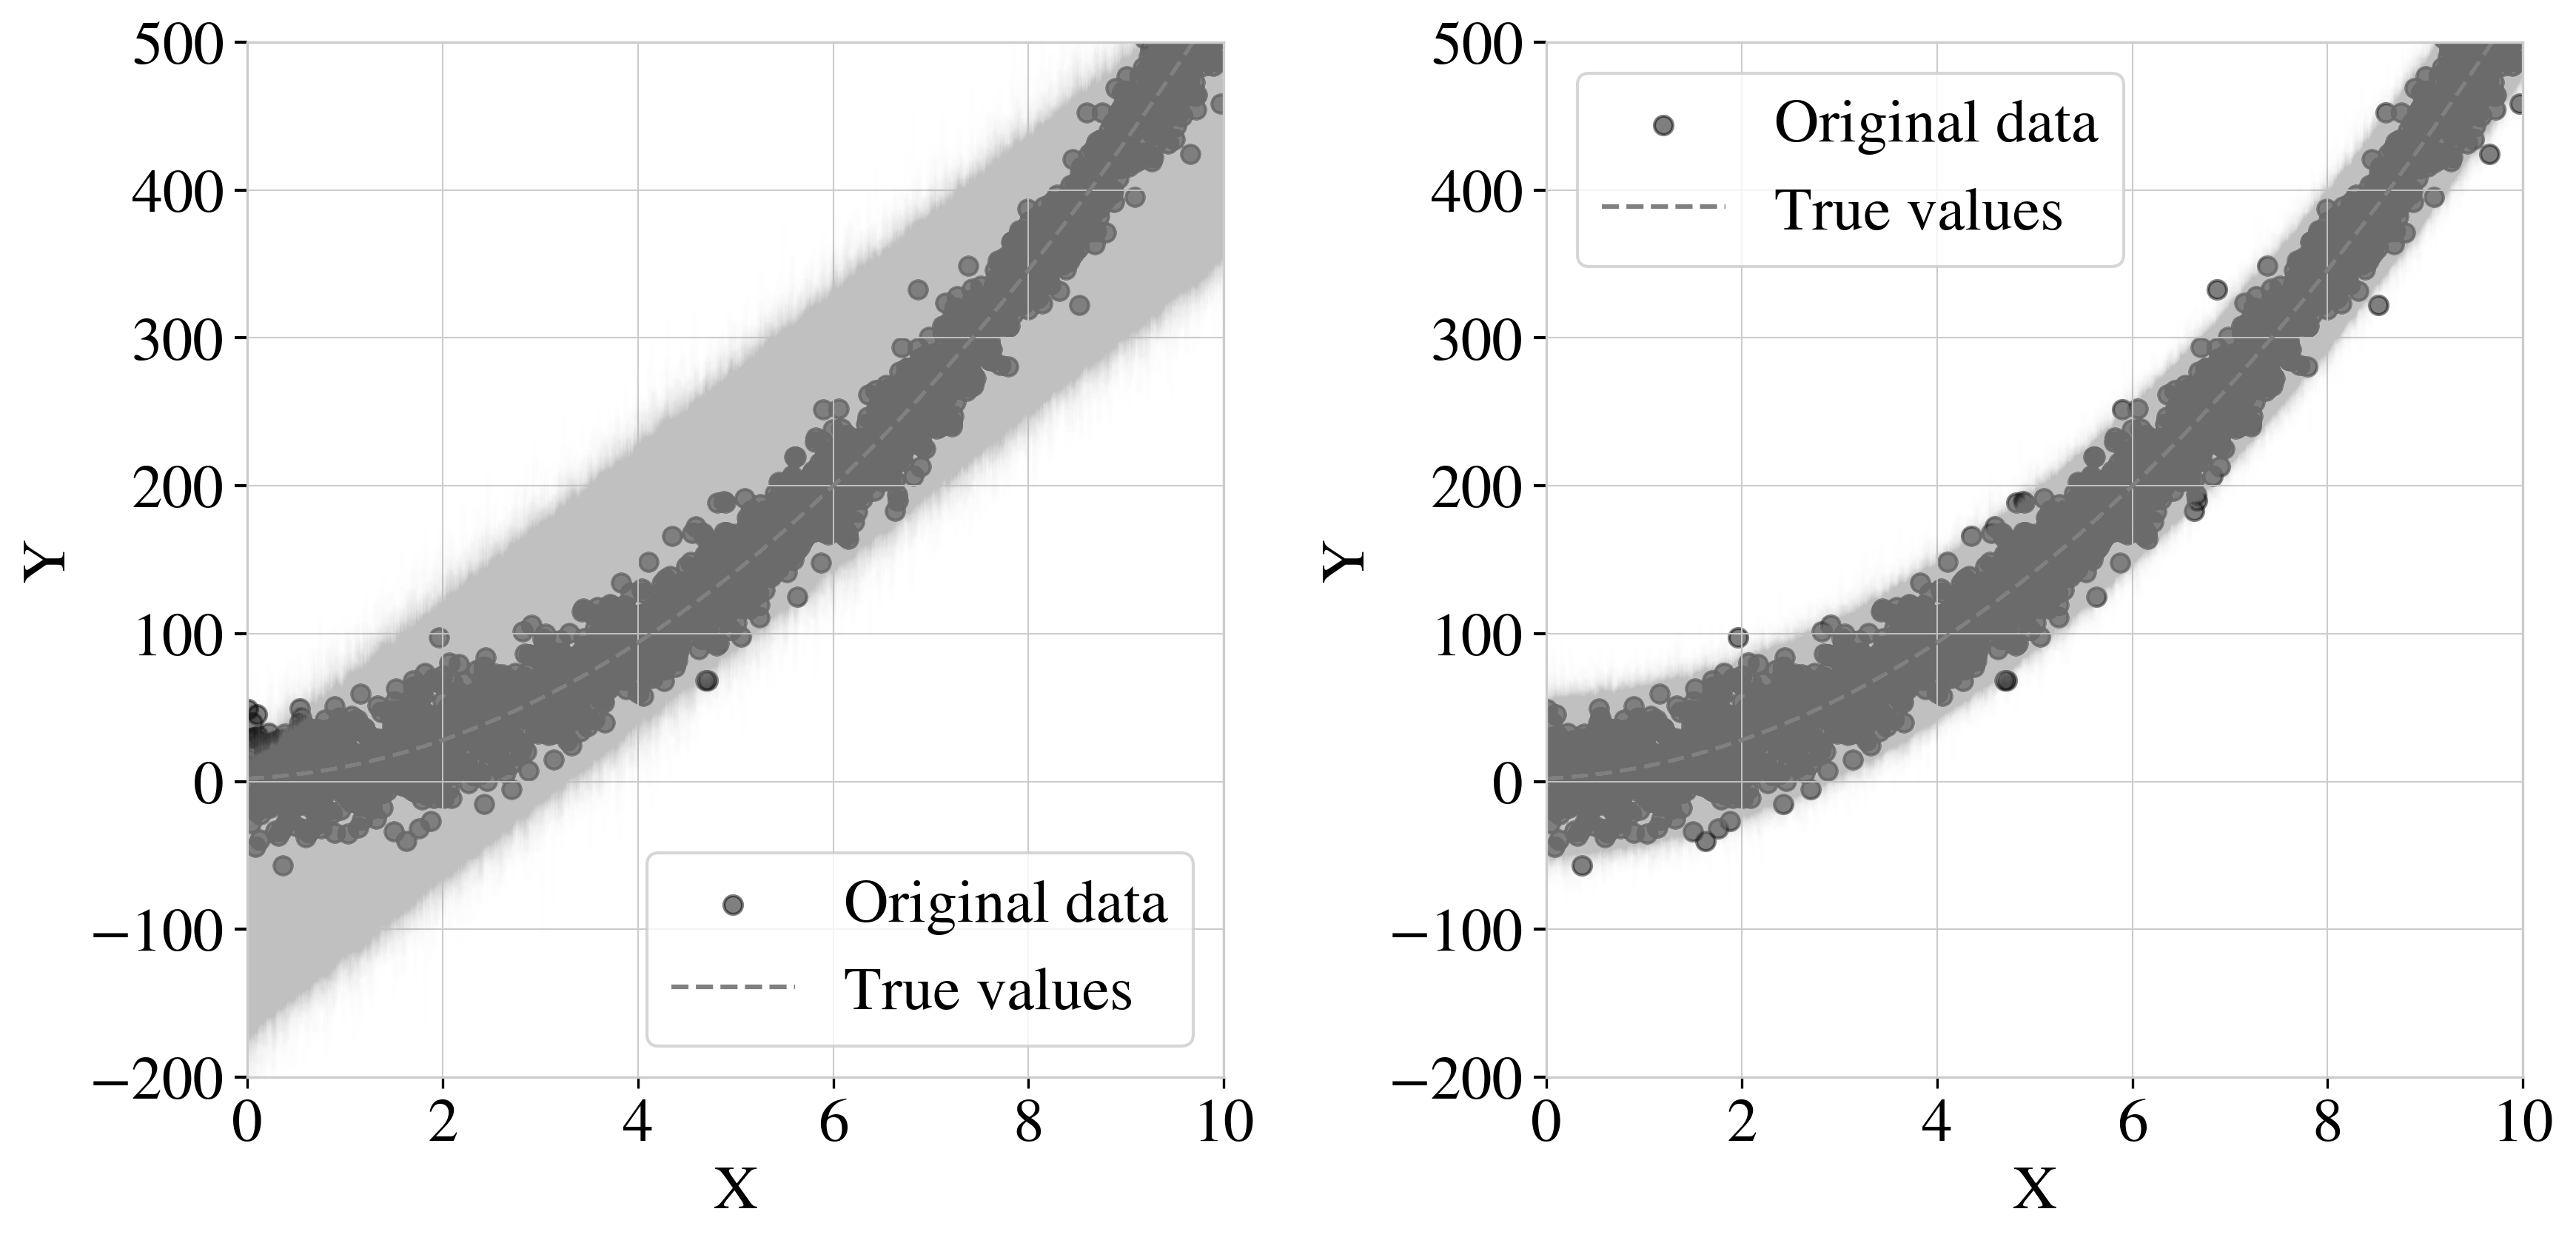

In [ ]:
# Plotting the generated data together with the original data
plt.figure(figsize=(12, 6))

# Original data and linear model
plt.subplot(1, 2, 1)
plt.scatter(x, y, label='Original data', color='k', alpha=0.5)
plt.plot(x, true_intercept + true_slope * x + true_quad_coeff * x**2, color='gray', linestyle='--', label='True values')
plt.plot(x, post_pred_linear.posterior_predictive['y_linear'][0,:,:].T, color='silver', alpha=0.01)
# plt.title('Linear model')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim([0, 10])
plt.ylim([-200, 500])
plt.legend()

# Original data and quadratic model
plt.subplot(1, 2, 2)
plt.scatter(x, y, label='Original data', color='k', alpha=0.5)
plt.plot(x, true_intercept + true_slope * x + true_quad_coeff * x**2, color='gray', linestyle='--', label='True values')
plt.plot(x, post_pred_quad.posterior_predictive['y_quad'][0,:,:].T, color='silver', alpha=0.01)
# plt.title('Quadratic model')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim([0, 10])
plt.ylim([-200, 500])
plt.legend()

plt.tight_layout()
plt.show()

# Benchmark 2: Sinusoidal Model (Section 4.2)

In [ ]:
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

%config InlineBackend.figure_format = 'retina'
# az.style.use("arviz-darkgrid")

Generating Data

In [ ]:
size = 2000
x = np.linspace(0, 2, size)
y = np.zeros(len(x))

In [ ]:
true_a = 4
true_b = 2

In [ ]:
true_values = true_a*np.sin(true_b*x)

sigma = 0.3
noise = np.random.randn(size)*sigma
# add noise
noisy_values = true_values + noise

data = pd.DataFrame(dict(x=x, y=y))

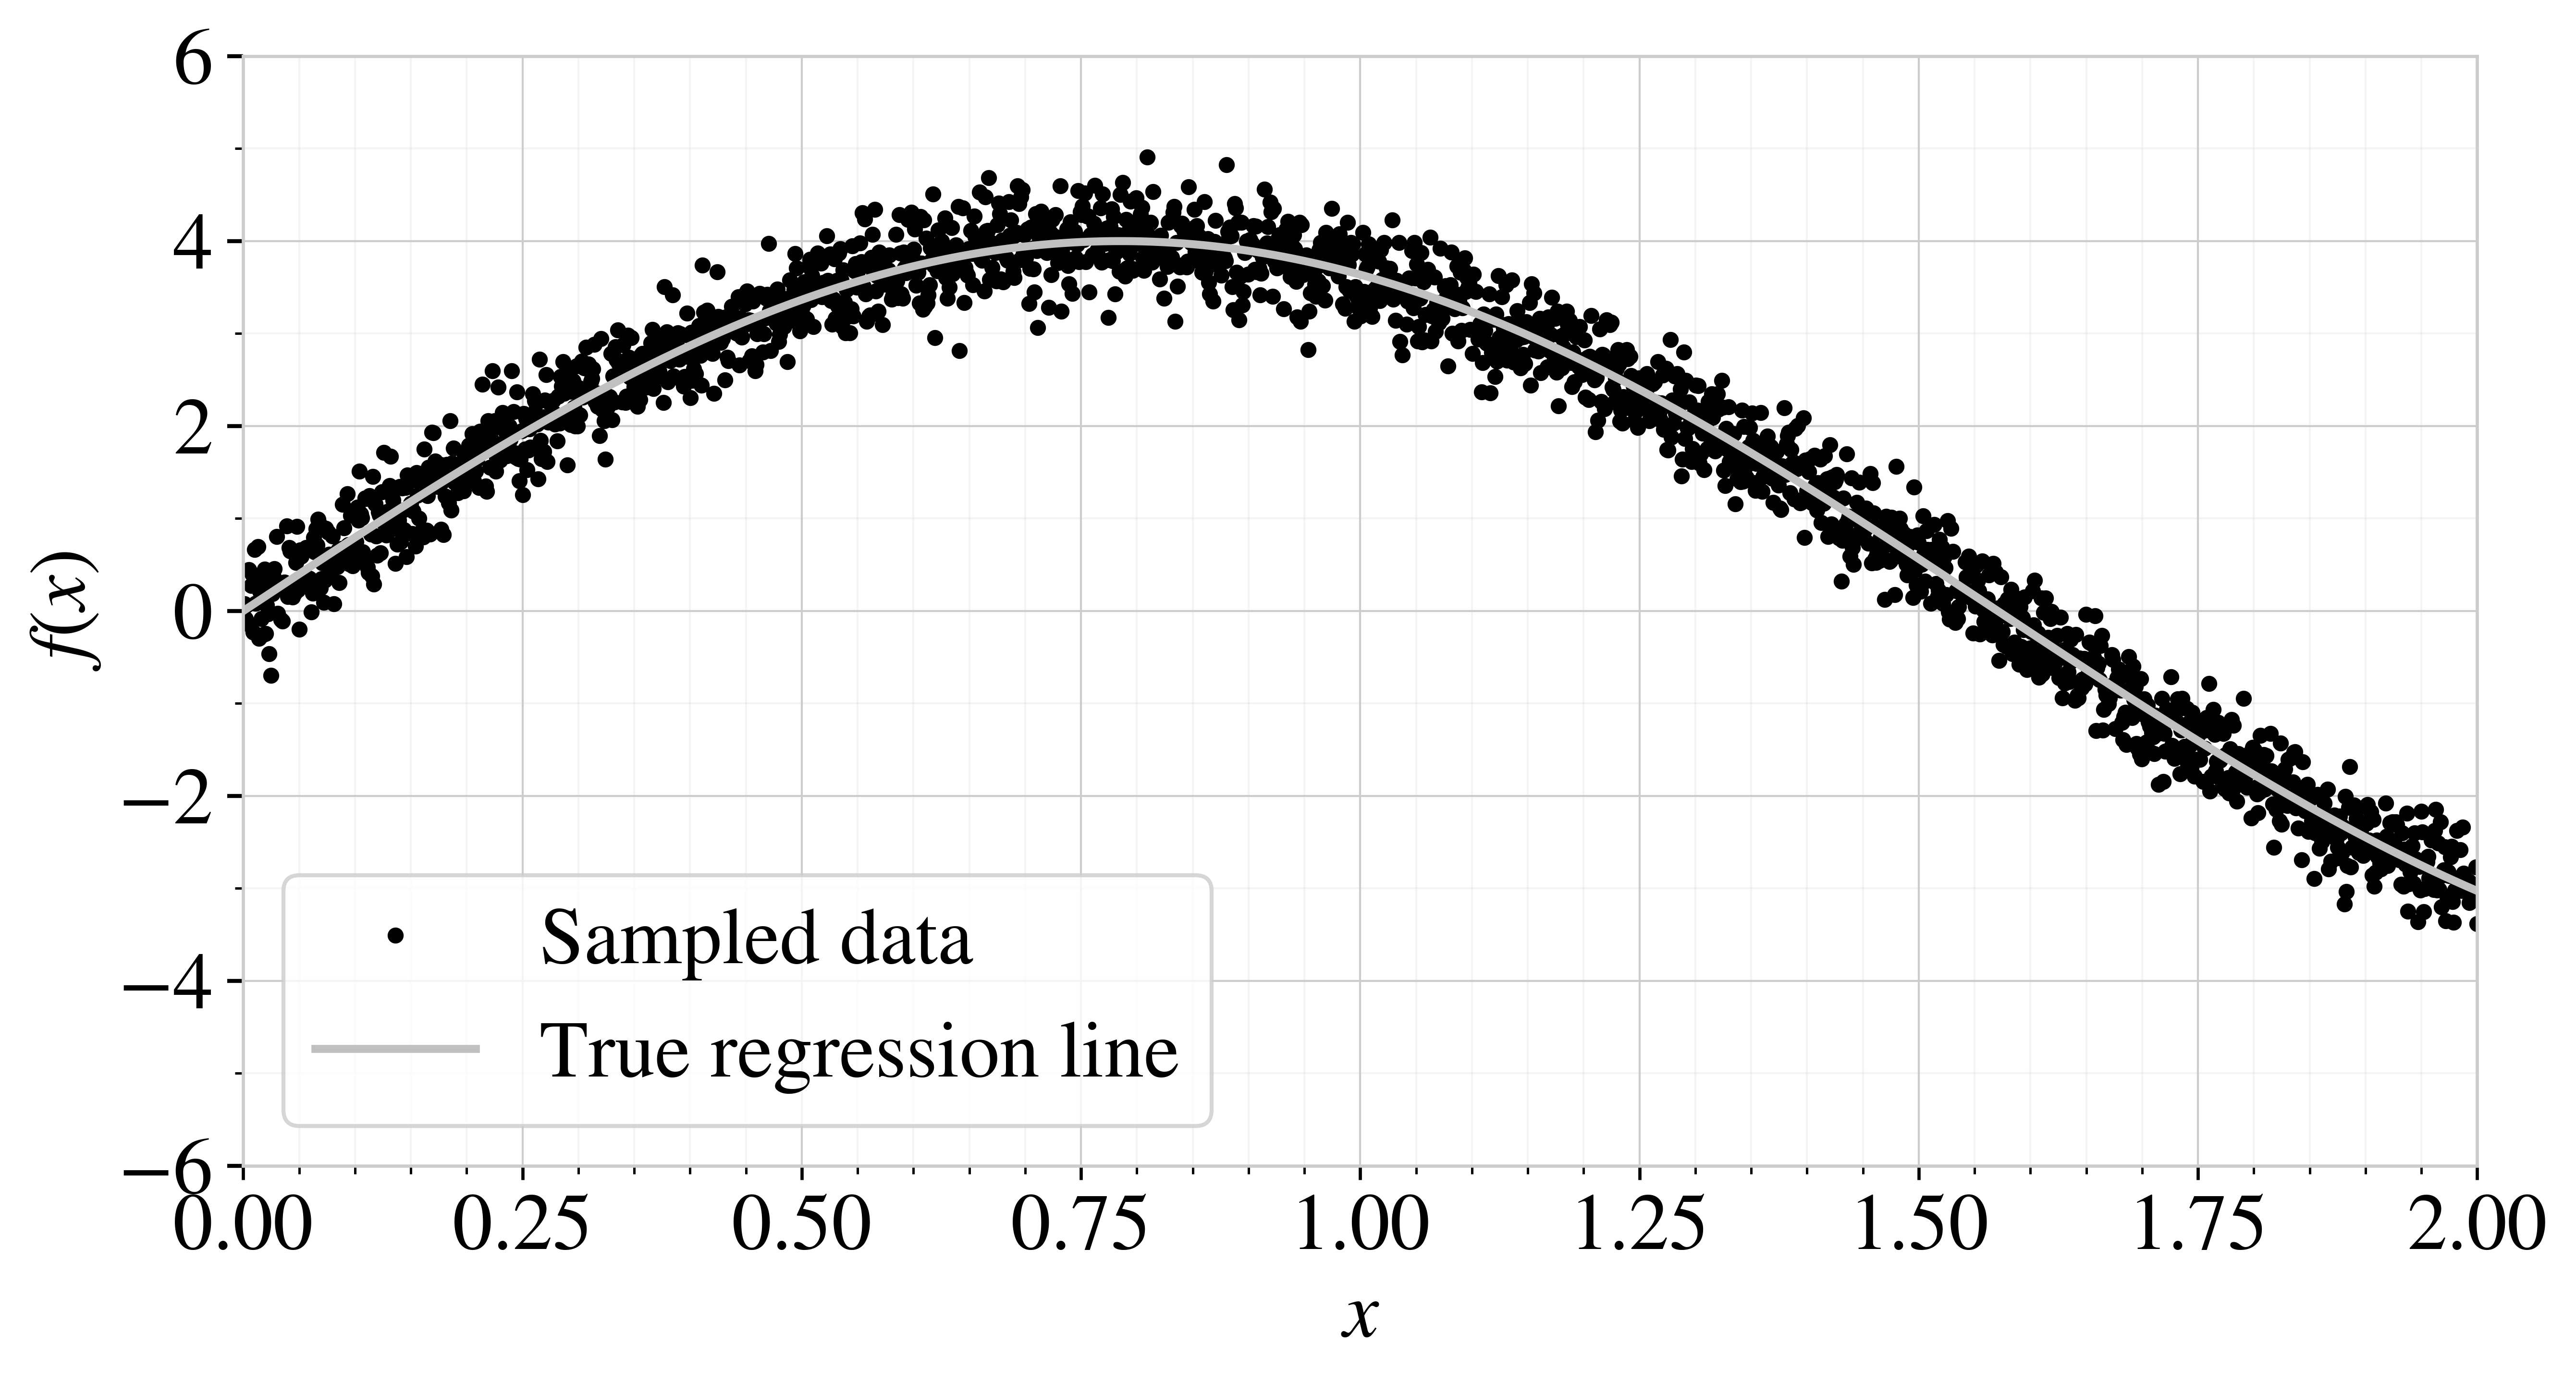

In [ ]:
fig = plt.figure(figsize=(10,5))
# ax = fig.add_subplot(111, xlabel="X", ylabel="Y", title="Generated data and underlying model")
ax = fig.add_subplot(111, xlabel="$x$", ylabel="$f(x)$")

ax.plot(x, noisy_values, ".", label="Sampled data", color='k')
ax.plot(x, true_values, color='silver', label="True regression line", lw=2.0)

plt.xlim([0, 2])
plt.ylim([-6, 6])
plt.legend(loc=0);

ax.grid(which='minor', alpha=0.2)
ax.yaxis.grid(True, which='minor')
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(1))

plt.show()

Defining Taylor Series

In [ ]:
y = np.zeros(size)

In [ ]:
# Taylor approximation at x0 of the function 'function'
def taylor(a, b, i, size):
    y = np.zeros(size)
    for n in range(i):
      y = y + a*(((-1)**n * (b*x)**(2*n+1)) / np.math.factorial(2*n+1))
    return y

In [ ]:
taylor5_ex = taylor(true_a, true_b, 5, size)

AttributeError: module 'numpy' has no attribute 'math'

In [ ]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, xlabel="X", ylabel="Y", title="Generated data and underlying model")
ax.plot(x, noisy_values, ".", label="Sampled data", color='k')
ax.plot(x, taylor5_ex, label="Maclaurin Series of degree 5", color='gray')

plt.xlim([0, 2])
plt.ylim([-6, 6])
plt.legend(loc=0);

ax.grid(which='minor', alpha=0.2)
ax.yaxis.grid(True, which='minor')
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(1))

plt.show()

Analyzing the model

In [ ]:
# Definir el modelo lineal
with pm.Model() as taylor3_model:
    # Priors
    A = pm.Normal('A', mu=0, sigma=10)
    B = pm.Normal('B', mu=0, sigma=10)
    noise = pm.HalfNormal('noise', sigma=1)

    # Modelo grado 3
    taylor3 = taylor(A, B, 3, size)

    # Likelihood
    likelihood = pm.Normal('y_taylor3', mu=taylor3, sigma=noise, observed=noisy_values)

    # Sample
    taylor3_trace = pm.sample(1000, tune=500)

with pm.Model() as taylor5_model:
    # Priors
    A = pm.Normal('A', mu=1, sigma=10)
    B = pm.Normal('B', mu=1, sigma=10)
    noise = pm.HalfNormal('noise', sigma=1)

    # Modelo grado 5
    taylor5 = taylor(A, B, 5, size)

    # Likelihood
    likelihood = pm.Normal('y_taylor5', mu=taylor5, sigma=noise, observed=noisy_values)

    # Sample
    taylor5_trace = pm.sample(1000, tune=500)

with pm.Model() as sinx_model:
    # Priors
    A = pm.Normal('A', mu=1, sigma=10)
    B = pm.Normal('B', mu=1, sigma=10)
    noise = pm.HalfNormal('noise', sigma=1)

    # Modelo grado 5
    sin_model = A*np.sin(B*x)

    # Likelihood
    likelihood = pm.Normal('y_sinx', mu=sin_model, sigma=noise, observed=noisy_values)

    # Sample
    sin_trace = pm.sample(1000, tune=500)

In [ ]:
# fig = plt.figure(figsize=(30,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(taylor3_trace.posterior.A[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('A')
plt.ylabel('PDF')
plt.xlim([2.45, 2.85])
plt.ylim([0, 8])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.01))
ax1.yaxis.set_minor_locator(MultipleLocator(0.2))

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

ax2 = az.plot_dist(taylor3_trace.posterior.B[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('B')
plt.ylabel('PDF')
plt.xlim([1.66, 1.76])
plt.ylim([0, 40])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.005))
ax2.yaxis.set_minor_locator(MultipleLocator(1))

plt.show()

# # Tercer  subgráfico
# plt.subplot(1, 3, 3)

ax3 = az.plot_dist(taylor3_trace.posterior.noise[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('Sigma')
plt.ylabel('PDF')
plt.xlim([1.65, 1.90])
plt.ylim([0, 14])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(1))
ax3.yaxis.set_minor_locator(MultipleLocator(1))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# fig = plt.figure(figsize=(30,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(taylor5_trace.posterior.A[0], rug=True, color='k')
# plt.title('Taylor Series of degree 5')
plt.xlabel('A')
plt.ylabel('PDF')
plt.xlim([3.97, 4.05])
plt.ylim([0, 40])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.005))
ax1.yaxis.set_minor_locator(MultipleLocator(1))

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

ax2 = az.plot_dist(taylor5_trace.posterior.B[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('B')
plt.ylabel('PDF')
plt.xlim([2.006, 2.020])
plt.ylim([0, 200])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.001))
ax2.yaxis.set_minor_locator(MultipleLocator(5))

plt.show()

# # Tercer  subgráfico
# plt.subplot(1, 3, 3)

ax3 = az.plot_dist(taylor5_trace.posterior.noise[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('Sigma')
plt.ylabel('PDF')
plt.xlim([0.285, 0.32])
plt.ylim([0, 100])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.001))
ax3.yaxis.set_minor_locator(MultipleLocator(5))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# fig = plt.figure(figsize=(30,5))

# # Primer subgráfico
# plt.subplot(1, 3, 1)

ax1 = az.plot_dist(sin_trace.posterior.A[0], rug=True, color='k')
# plt.title('Taylor Series of degree 5')
plt.xlabel('A')
plt.ylabel('PDF')
plt.xlim([3.97, 4.05])
plt.ylim([0, 50])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.005))
ax1.yaxis.set_minor_locator(MultipleLocator(2))

plt.show()

# # Segundo  subgráfico
# plt.subplot(1, 3, 2)

ax2 = az.plot_dist(sin_trace.posterior.B[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('B')
plt.ylabel('PDF')
plt.xlim([1.990, 2.006])
plt.ylim([0, 250])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.001))
ax2.yaxis.set_minor_locator(MultipleLocator(10))

plt.show()

# # Tercer  subgráfico
# plt.subplot(1, 3, 3)

ax3 = az.plot_dist(sin_trace.posterior.noise[0], rug=True, color='k')
# plt.title('Taylor Series of degree 3')
plt.xlabel('Sigma')
plt.ylabel('PDF')
plt.xlim([0.29, 0.32])
plt.ylim([0, 100])

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.001))
ax3.yaxis.set_minor_locator(MultipleLocator(5))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# Generar nuevos datos utilizando los parámetros de los modelos ajustados
with taylor3_model:
    post_pred_taylor3 = pm.sample_posterior_predictive(taylor3_trace)
    # Perform MAP estimation
    taylor3_MAP = pm.find_MAP()

with taylor5_model:
    post_pred_taylor5 = pm.sample_posterior_predictive(taylor5_trace)
    # Perform MAP estimation
    taylor5_MAP = pm.find_MAP()

with sinx_model:
    post_pred_sin = pm.sample_posterior_predictive(sin_trace)
    # Perform MAP estimation
    sin_MAP = pm.find_MAP()

In [ ]:
plt.rcParams['figure.dpi'] = 200

In [ ]:
post_pred_taylor3.posterior_predictive['y_taylor3'][0,0,0]

In [ ]:
# Plotear los datos generados junto con los datos originales
plt.figure(figsize=(10,5))

# Datos originales y ajustes lineales
# plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
plt.plot(x, post_pred_taylor3.posterior_predictive['y_taylor3'][0,:,:].T, color='silver', alpha=0.01)
plt.plot(x, noisy_values, ".", label='Sampled data', color='k')
plt.plot([0, 0], [-0.99946254, 0], label='Maclaurin Series of Degree 3', color='silver')

# plt.title('Taylor Serie - Deg. 3')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.xlim([0, 2])
plt.ylim([-7.5, 10])
plt.legend(loc="best")

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(0.05))
ax1.yaxis.set_minor_locator(MultipleLocator(1))

plt.tight_layout()
plt.show()

In [ ]:
# Plotear los datos generados junto con los datos originales
plt.figure(figsize=(10,5))

# Datos originales y ajustes lineales
# plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
plt.plot(x, post_pred_taylor5.posterior_predictive['y_taylor5'][0,:,:].T, color='silver')
plt.plot(x, noisy_values, ".", label='Sampled data', color='k')
plt.plot([0, 0], [-0.99946254, 0], label='Maclaurin Series of Degree 5', color='silver')

# plt.title('Taylor Serie - Deg. 5')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.xlim([0, 2])
plt.ylim([-6, 6])
plt.legend(loc="best")

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(MultipleLocator(1))

plt.tight_layout()
plt.show()

In [ ]:
# Plotear los datos generados junto con los datos originales
plt.figure(figsize=(10,5))

# Datos originales y ajustes lineales
# plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
plt.plot(x, post_pred_sin.posterior_predictive['y_sinx'][0,:,:].T, color='silver')
plt.plot([0, 0], [-0.99946254, 0], label='$Sin(x)$', color='silver')
plt.plot(x, noisy_values, ".", label='Sampled data', color='k')

# plt.title('Sin(x)')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.xlim([0, 2])
plt.ylim([-6, 6])
plt.legend(loc="best")

ax3.grid(which='minor', alpha=0.2)
ax3.yaxis.grid(True, which='minor')
ax3.xaxis.set_minor_locator(MultipleLocator(0.05))
ax3.yaxis.set_minor_locator(MultipleLocator(1))

plt.tight_layout()
plt.show()

In [ ]:
# post_pred_linear.posterior_predictive['y_linear'][0,:,:]

# Benchmark 3: Beam Deflection Model (Section 4.3)

In [ ]:
P = np.arange(0, 51, 0.1)
E_real = 24000 # MPa

In [ ]:
P.size

In [ ]:
sigma = 0.5
noise = np.random.randn(P.size)*sigma

In [ ]:
noise.std()

In [ ]:
noise.mean()

In [ ]:
def BasicBeam(P, Ebeam):

    E = Ebeam
    W = 8
    # P = np.array([35, 45, 60, 70, 100, 12, 18, 42, 34, 7, 27, 19, 10, 30, 52, 71, 102, 13, 28, 41])

    L = 3.9
    I = 102e-6
    a = 1.3
    b = 2.6
    x = 1.3

    # Loading I

    T_A_1 = -W*L**3/(24*E*I)
    y_c_1 = -W*(x**4-2*L*x**3+L**3*x)/(24*E*I)

    # Loading II

    T_A_2 = -P*b*(L**2-b**2)/(6*E*I*L)
    y_c_2 = -P*a**2*b**2/(3*E*I*L)

    Theta_A = T_A_1 + T_A_2
    y_c = y_c_1 + y_c_2


    # # Desplazamientos

    # Desplazamientos = np.transpose(np.array([Theta_A, y_c]))
    # Desplazamientos = np.reshape(Desplazamientos, (40, 1))

    return -y_c

In [ ]:
P = np.arange(0, 51, 0.1)
E_real = 24000 # MPa

sigma = 0.5
noise = np.random.randn(P.size)*sigma

def BasicBeam(P, Ebeam):

    E = Ebeam
    W = 8

    L = 3.9
    I = 102e-6
    a = 1.3
    b = 2.6
    x = 1.3

    # Loading I

    T_A_1 = -W*L**3/(24*E*I)
    y_c_1 = -W*(x**4-2*L*x**3+L**3*x)/(24*E*I)

    # Loading II

    T_A_2 = -P*b*(L**2-b**2)/(6*E*I*L)
    y_c_2 = -P*a**2*b**2/(3*E*I*L)

    Theta_A = T_A_1 + T_A_2
    y_c = y_c_1 + y_c_2

    return -y_c

In [ ]:
Desp_Teo = BasicBeam(P, 24e3)

print(Desp_Teo)

In [ ]:
# add noise
Desp_Exp = Desp_Teo + noise

In [ ]:
# Plotear los datos generados junto con los datos originales
fig, ax = plt.subplots(figsize=(10,5))

# Datos originales y ajustes lineales
ax.plot(Desp_Exp, P, ".", label='Sampled data', color='k')
ax.plot(Desp_Teo, P, label='Theoretical behaviour', color='silver')

# plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
# plt.plot(x, post_pred_sin.posterior_predictive['y_sinx'][0,:,:].T, color='silver', alpha=0.01)

ax.set_xlabel('Displacements [mm]')
ax.set_ylabel('P [N]')
ax.set_xlim([7.5, 30])
ax.set_ylim([0, 50])
ax.legend(loc="best")

ax.grid(which='minor', alpha=0.2)
ax.yaxis.grid(True, which='minor')
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(2))


plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as Model_BasicBeam:
    # Priors
    E = pm.Normal('Modulus', mu=20000, sigma=10000)
    noise = pm.HalfNormal('Sigma', sigma=1)

    # Modelo grado 5
    Model_BB = BasicBeam(P, E)

    # Likelihood
    likelihood = pm.Normal('y_BasicBeam', mu=Model_BB, sigma=noise, observed=Desp_Exp)

    # Sample
    BasicBeam_trace = pm.sample(1000, tune=500)

In [ ]:
BasicBeam_trace.posterior.Modulus[0]

In [ ]:
fig = plt.figure(figsize=(10,5))

ax1 = az.plot_dist(BasicBeam_trace.posterior.Modulus[0], rug=True, color='k', textsize=30)
plt.xlabel('Modulus of elasticity [MPa]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([23900, 24100])
plt.ylim([0, 0.015])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(10))
ax1.yaxis.set_minor_locator(MultipleLocator(0.001))

plt.show()

fig = plt.figure(figsize=(10,5))

# Segundo  subgráfico

ax2 = az.plot_dist(BasicBeam_trace.posterior.Sigma[0], rug=True, color='k', textsize=30)
plt.xlabel('Sigma', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([0.425, 0.575])
plt.ylim([0, 30])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.005))
ax2.yaxis.set_minor_locator(MultipleLocator(2))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# Generar nuevos datos utilizando los parámetros de los modelos ajustados
with Model_BasicBeam:
    post_pred_BasicBeam = pm.sample_posterior_predictive(BasicBeam_trace)
    # Perform MAP estimation
    BasicBeam_MAP = pm.find_MAP()

In [ ]:
post_pred_BasicBeam

In [ ]:
plt.rcParams['figure.dpi'] = 200

In [ ]:
post_pred_BasicBeam.posterior_predictive['y_BasicBeam'][0,0,0]

In [ ]:
# Plotear los datos generados junto con los datos originales
plt.figure(figsize=(10,5))

# Datos originales y ajustes lineales
# plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
plt.plot(post_pred_BasicBeam.posterior_predictive['y_BasicBeam'][0,:,:].T, P, color='silver', alpha=0.01)
plt.plot(Desp_Exp, P, ".", label='Sampled data', color='k')
plt.plot([0, 0], [-0.99946254, 0], label='Euler-Bernoulli Theory', color='silver')

# plt.title('Taylor Serie - Deg. 3')
plt.xlabel('Displacements [mm]')
plt.ylabel('P [N]')
plt.xlim([7.5, 30])
plt.ylim([0, 50])
plt.legend(loc="best")

# ax1.grid(which='minor', alpha=0.2)
# ax1.yaxis.grid(True, which='minor')
# ax1.xaxis.set_minor_locator(MultipleLocator(0.5))
# ax1.yaxis.set_minor_locator(MultipleLocator(2))

plt.tight_layout()
plt.show()

In [ ]:
axes = az.plot_posterior(
    BasicBeam_trace,
    var_names=["Modulus", "Sigma"],
    figsize=(11.5, 5),
)

fig = axes.flatten()[0].get_figure()
# fig.suptitle("Centered Eight: mu and theta for Choate")

plt.show()

In [ ]:
# az.to_netcdf(idata, DirName+'/TraceAA')

In [ ]:
# trace = az.from_netcdf(DirName+'TraceAA')
# az.plot_trace(trace)

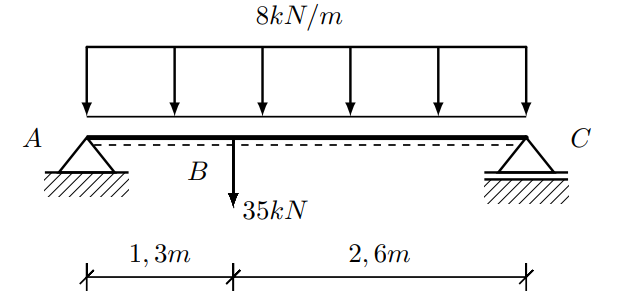

## Beam OpenSeepy OP 

In [ ]:
def BasicBeamOP(P, input):

    Ebeam = input[0]

    Desplazamientos = [0]

    for i in range(len(P)):

        meter = 1;
        N = 1;
        sec = 1;

        # Dependent units
        sq_meter = meter*meter;
        Pa = N/sq_meter;
        kPa = Pa/1000;

        # Constants
        g = 9.81*meter/(sec*sec);
        pi = math.acos(-1);

        # ------------------------------
        # Start of model generation
        # -----------------------------

        # remove existing model
        wipe()

        # set modelbuilder
        model('basic', '-ndm', 2, '-ndf', 3)

        # create nodes
        node(1, 0.0, 0.0)
        node(2, 1.3, 0.0)
        node(3, 1.95, 0.0)
        node(4, 3.9, 0.0)

        # set boundary condition

        fix(1, 1, 1, 0)
        fix(4, 0, 1, 0)

        # define materials
        uniaxialMaterial("Elastic", 1, Ebeam)

        # Define beams
        geomTransf('Linear', 1, 0, 0, 1);

        # define elements

        I = 102e-6
        lado = np.cbrt(12*I)
        Area = lado*lado

        element('elasticBeamColumn', 1, 1, 2, Area, Ebeam, I, 1)
        element('elasticBeamColumn', 2, 2, 3, Area, Ebeam, I, 1)
        element('elasticBeamColumn', 3, 3, 4, Area, Ebeam, I, 1)

        # create TimeSeries
        timeSeries("Linear", 1)

        # create a plain load pattern
        pattern("Plain", 1, 1)

        # Create the nodal load - command: load nodeID xForce yForce
        eleLoad('-ele', 1, '-type', '-beamUniform', -8.0)
        eleLoad('-ele', 2, '-type', '-beamUniform', -8.0)
        eleLoad('-ele', 3, '-type', '-beamUniform', -8.0)

        # Create the nodal load - command: load nodeID xForce yForce
        load(2, 0.0, float(-P[i]), 0.0)

        # ------------------------------
        # Start of analysis generation
        # ------------------------------

        # create SOE
        # system("BandSPD")

        system("FullGeneral")

        # create DOF number
        numberer("RCM")

        # create constraint handler
        constraints("Plain")

        # create integrator
        integrator("LoadControl", 1.0)

        # create algorithm
        algorithm("Linear")

        # create analysis object
        analysis("Static")

        # perform the analysis
        analyze(1)

        tz = nodeDisp(1,3)
        uy = nodeDisp(2,2)

        Desplazamientos = np.vstack((Desplazamientos, uy))

    Desplazamientos = np.delete(Desplazamientos, 0, 0)
    Desplazamientos = np.reshape(Desplazamientos, (510, 1))
    Desplazamientos = Desplazamientos.flatten()

    #     Desplazamientos = np.vstack((Desplazamientos, [tz, uy]))

    # Desplazamientos = np.delete(Desplazamientos, 0, 0)
    # Desplazamientos = np.reshape(Desplazamientos, (40, 1))

    return -Desplazamientos

In [ ]:
# P = np.array([35, 45, 60, 70, 100, 12, 18, 42, 34, 7, 27, 19, 10, 30, 52, 71, 102, 13, 28, 41])
# data = BasicBeam(P,24e3)

In [ ]:
data = Desp_Exp
input = [24000]
Desp_Exp_2 = BasicBeamOP(P, input)
# Desp_Exp_2 = Desp_Exp_2.flatten()
# Desp_Exp_2

In [ ]:
def loglikeBasicBeam(theta, sigma, x, data):
    model = BasicBeamOP(P, theta)
    try:
        log = -0.5 * ((data - model) / sigma) ** 2 - np.log(np.sqrt(2 * np.pi)) - np.log(sigma)
    except:
        log = -0.5 * ((1e10) / sigma) ** 2 - np.log(np.sqrt(2 * np.pi)) - np.log(sigma)
    return log

#########################
my_loglike = loglikeBasicBeam

def custom_dist_loglike(data, sigma, P, *thetas):
    return loglikewithgrad_op(*thetas, sigma, P, data)

In [ ]:
# logl = LogLike(loglikeBasicBeam, data, P)
with pm.Model() as m_VigaSimple:
  E = pm.Normal('E', mu=24e3 , sigma= 4e3)
  sigma = pm.HalfNormal('sigma')
  theta = pt.as_tensor_variable([E])
  ## -------------------------- LIKELIHOOD --------------------------
  # pm.Potential("likelihood", logl(theta, sigma))
  likelihood = pm.CustomDist(
        "likelihood", sigma, P,theta, observed=data, logp=custom_dist_loglike
    )
  ## -------------------------- STEP AND SAMPLE --------------------------
  # idata = pm.sample(chains = 2)
  idata = pm.sample(1000, tune=500)

In [ ]:
idata.posterior.E[0]

In [ ]:
fig = plt.figure(figsize=(10,5))

ax1 = az.plot_dist(idata.posterior.E[0], rug=True, color='k', textsize=30)
plt.xlabel('Modulus of elasticity [MPa]', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([23900, 24050])
plt.ylim([0, 0.015])

ax1.grid(which='minor', alpha=0.2)
ax1.yaxis.grid(True, which='minor')
ax1.xaxis.set_minor_locator(MultipleLocator(10))
ax1.yaxis.set_minor_locator(MultipleLocator(0.001))

plt.show()

fig = plt.figure(figsize=(10,5))

# Segundo  subgráfico

ax2 = az.plot_dist(idata.posterior.sigma[0], rug=True, color='k', textsize=30)
plt.xlabel('Sigma', fontsize=30)
plt.ylabel('PDF', fontsize=30)
plt.xlim([0.44, 0.54])
plt.ylim([0, 30])

ax2.grid(which='minor', alpha=0.2)
ax2.yaxis.grid(True, which='minor')
ax2.xaxis.set_minor_locator(MultipleLocator(0.005))
ax2.yaxis.set_minor_locator(MultipleLocator(2))

# Ajustar el diseño de los subgráficos
plt.tight_layout()

plt.show()

In [ ]:
# Generar nuevos datos utilizando los parámetros de los modelos ajustados
with m_VigaSimple:
    post_pred_m_VigaSimple = pm.sample_posterior_predictive(idata, extend_inferencedata=True)
    # # Perform MAP estimation
    # m_VigaSimple_MAP = pm.find_MAP()

In [ ]:
post_pred_m_VigaSimple

In [ ]:
post_pred_m_VigaSimple.E[0,:]

In [ ]:
# # Plotear los datos generados junto con los datos originales
# plt.figure(figsize=(10,5))

# # Datos originales y ajustes lineales
# # plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
# plt.plot(post_pred_m_VigaSimple.E[0,:].T, P, color='silver', alpha=0.01)
# plt.plot(noisy_values, P, ".", label='Sampled data', color='k')
# plt.plot([0, 0], [-0.99946254, 0], label='Openseespy Model', color='silver')

# # # plt.title('Taylor Serie - Deg. 3')
# # plt.xlabel('$x$')
# # plt.ylabel('$f(x)$')
# # plt.xlim([0, 2])
# # plt.ylim([-7.5, 10])
# # plt.legend(loc="best")

# # ax1.grid(which='minor', alpha=0.2)
# # ax1.yaxis.grid(True, which='minor')
# # ax1.xaxis.set_minor_locator(MultipleLocator(0.05))
# # ax1.yaxis.set_minor_locator(MultipleLocator(1))

# plt.tight_layout()
# plt.show()

In [ ]:
# # Plotear los datos generados junto con los datos originales
# plt.figure(figsize=(10,5))

# # Datos originales y ajustes lineales
# # plt.plot(x, true_values, color='gray', linestyle='--', label='True model')
# plt.plot(post_pred_m_VigaSimple.posterior_predictive['E'][0,:,:].T, P, color='silver', alpha=0.01)
# plt.plot(noisy_values, P, ".", label='Sampled data', color='k')
# plt.plot([0, 0], [-0.99946254, 0], label='Openseespy Model', color='silver')

# # # plt.title('Taylor Serie - Deg. 3')
# # plt.xlabel('$x$')
# # plt.ylabel('$f(x)$')
# # plt.xlim([0, 2])
# # plt.ylim([-7.5, 10])
# # plt.legend(loc="best")

# # ax1.grid(which='minor', alpha=0.2)
# # ax1.yaxis.grid(True, which='minor')
# # ax1.xaxis.set_minor_locator(MultipleLocator(0.05))
# # ax1.yaxis.set_minor_locator(MultipleLocator(1))

# plt.tight_layout()
# plt.show()

In [ ]:
# az.to_netcdf(idata, DirName+'/TraceBB')